In [1]:
from utils.utils import *

structures_path = "1.Minimal_structures/Minimal_structures"

Cif.path = structures_path
Cif.original_cifs_path = "/home/fnerin/Desktop/AlloPockets/src/data" # <pdb>_updated.cif.gz

# allodb

In [2]:
import sys
sys.path.append("..")

from src import *

db.init('../database.db')
dbpdbs = set(i.entry_id for i in PDB.select())
db.close()

True

# Data

In [3]:
clustersf = "2.Clustering/mmseqs2/clusters.pkl"

representatives = pd.read_pickle(clustersf).pdb.unique().tolist()

representatives

['6ta3',
 '5kwj',
 '6t4k',
 '5mo6',
 '3o0n',
 '1tjp',
 '2nw8',
 '4bqh',
 '1og0',
 '3s8b',
 '6ncf',
 '5jv1',
 '3auy',
 '5dl1',
 '7bhu',
 '1qqb',
 '2p5m',
 '6hgj',
 '4aau',
 '4cff',
 '7juv',
 '4mbs',
 '6nzf',
 '3zkr',
 '5uyy',
 '5xez',
 '2b08',
 '2c2b',
 '1raf',
 '5mfv',
 '2xje',
 '3i0s',
 '4dpq',
 '2d5x',
 '7amj',
 '2qmx',
 '3e5u',
 '6q4k',
 '4bo1',
 '6mo1',
 '2him',
 '2poc',
 '5ja7',
 '6rkw',
 '5aa4',
 '4yw8',
 '5fts',
 '5h08',
 '5olk',
 '3kq7',
 '2qei',
 '8jii',
 '3u18',
 '5y66',
 '6pgr',
 '2ha2',
 '5dzh',
 '7anw',
 '6kx3',
 '6e5g',
 '4pcu',
 '6bky',
 '1hak',
 '6gfm',
 '4ejl',
 '5lu8',
 '1fx2',
 '6fmz',
 '5f2e',
 '1o0s',
 '5w40',
 '6r4d',
 '7ehm',
 '6o0h',
 '4a79',
 '3dc2',
 '6ueg',
 '3kh5',
 '6u26',
 '8hnn',
 '5ngz',
 '7mew',
 '5m1a',
 '3nwy',
 '4q0a',
 '3rhw',
 '3smq',
 '5hue',
 '4lrl',
 '5urj',
 '7ofu',
 '6huj',
 '1hkb',
 '2ldb',
 '2cdq',
 '5lvx',
 '2dz9',
 '1njj',
 '3la2',
 '1uxq',
 '1vst',
 '4mdk',
 '6bvn',
 '1jlr',
 '5fii',
 '6sbv',
 '4bxc',
 '5ifu',
 '7ljc',
 '2jfz',
 '6o0n',
 

In [4]:
seqsf = "2.Clustering/seqs.pkl"

with open(seqsf, "rb") as f:
    seqs = {}
    for (pdb, entity_id, asym_id), seq in tqdm(pickle.load(f).items(), smoothing=0):
        if pdb in representatives:
            if pdb not in seqs:
                seqs[pdb] = {}
            seqs[pdb][entity_id] = seq
        
seqs

  0%|          | 0/3518 [00:00<?, ?it/s]

{'5kwj': {'1': 'MFSRPGLPVEYLQVPSASMGRDIKVQFQGGGPHAVYLLDGLRAQDDYNGWDINTPAFEEYYQSGLSVIMPVGGQSSFYTDWYQPSQSNGQNYTYKWETFLTREMPAWLQANKGVSPTGNAAVGLSMSGGSALILAAYYPQQFPYAASLSGFLNPSEGWWPTLIGLAMNDSGGYNANSMWGPSSDPAWKRNDPMVQIPRLVANNTRIWVYCGNGTPSDLGGDNIPAKFLEGLTLRTNQTFRDTYAADGGRNGVFNFPPNGTHSWPYWNEQLVAMKADIQHVLNGATPPAAPAAPAALEHHHHHH'},
 '6t4k': {'1': 'GSSHHHHHHSSGLVPRGSHMASLTEIEHLVQSVCKSYRETCQLRLEDLLRQRSNIFSREEVTGYQRKSMWEMWERCAHHLTEAIQYVVEFAKRLSGFMELCQNDQIVLLKAGAMEVVLVRMCRAYNADNRTVFFEGKYGGMELFRALGCSELISSIFDFSHSLSALHFSEDEIALYTALVLINAHRPGLQEKRKVEQLQYNLELAFHHHLHKTHRQSILAKLPPKGKLRSLCSQHVERLQIFQHLHPIVVQAAFPPLYKELFS'},
 '5mo6': {'1': 'GSMDIEFDDDADDDGSGSGSGSGSSGPVPSRARVYTDVNTHRPSEYWDYESHVVEWGNQDDYQLVRKLGRGKYSEVFEAINITNNEKVVVKILKPVKKKKIKREIKILENLRGGPNIITLADIVKDPVSRTPALVFEHVNNTDFKQLYQTLTDYDIRFYMYEILKALDYCHSMGIMHRDVKPHNVMIDHEHRKLRLIDWGLAEFYHPGQEYNVRVASRYFKGPELLVDYQMYDYSLDMWSLGCMLASMIFRKEPFFHGHDNYDQLVRIAKVLGTEDLYDYIDKYNIELDPRFNDILGRHSRKRWERFVHSENQHLVSPEALDFLDKLLRYDHQSRLTAREAMEHPYFYTVVK'},
 '3o0n': {'1': 'MKLSDL

In [5]:
len(seqs)

431

# PDB search

In [6]:
extra_path = "7.Extra_set"

os.makedirs(extra_path, exist_ok=True)

In [7]:
extra_original_cifs_path = f"{extra_path}/origcifs"
os.makedirs(extra_original_cifs_path, exist_ok=True)

extra_structures_path = f"{extra_path}/cifs"
os.makedirs(extra_structures_path, exist_ok=True)

extra_pockets_path = f"{extra_path}/pockets"
os.makedirs(extra_pockets_path, exist_ok=True)

extra_features_path = extra_path
os.makedirs(f"{extra_features_path}/features", exist_ok=True)

In [8]:
from utils.new_pdbs import Pdb

In [9]:
Cif.path = extra_structures_path
Cif.original_cifs_path = extra_original_cifs_path # <pdb>_updated.cif.gz
Pdb.path = extra_structures_path

## Query

In [10]:
from rcsbsearchapi.search import AttributeQuery, TextQuery

In [11]:
text = TextQuery("alloster*")

new = AttributeQuery(
            attribute="rcsb_accession_info.initial_release_date",
            operator="greater",
            value="2020-01-01||"
        )

In [12]:
searchf = f"{extra_path}/pdbs_search.pkl"

if not os.path.isfile(searchf):
    search = list( (text & new)() )
    existing = [p for p in search if p.lower() in dbpdbs]
    print("Already in db:", existing)
    search = sorted( set(search) - set(existing) )
    
    with open(searchf, "wb") as f:
        pickle.dump(search, f)
        
else:
    with open(searchf, "rb") as f:
        search = pickle.load(f)

len(search), search

(2104,
 ['10AD',
  '20XX',
  '21DU',
  '22MJ',
  '5S6X',
  '5S6Y',
  '5S6Z',
  '5S70',
  '5S71',
  '5S72',
  '5SA4',
  '5SA5',
  '5SA6',
  '5SA7',
  '5SA8',
  '5SA9',
  '5SAA',
  '5SAB',
  '5SAC',
  '5SAD',
  '5SAE',
  '5SAF',
  '5SAG',
  '5SAH',
  '5SAI',
  '5SBF',
  '6JIG',
  '6JL8',
  '6JOY',
  '6JP9',
  '6JT7',
  '6JT8',
  '6JT9',
  '6KA0',
  '6KA1',
  '6KMY',
  '6KN2',
  '6KN3',
  '6KN9',
  '6KNO',
  '6KNP',
  '6KSH',
  '6KSQ',
  '6KX2',
  '6L0C',
  '6L59',
  '6LCN',
  '6LIL',
  '6LK4',
  '6LNK',
  '6LNN',
  '6LOX',
  '6LPI',
  '6LZ6',
  '6LZ8',
  '6N2W',
  '6N57',
  '6N58',
  '6NTU',
  '6O56',
  '6OBJ',
  '6OUL',
  '6OY8',
  '6OYB',
  '6OYE',
  '6OYG',
  '6P1K',
  '6P3D',
  '6P4V',
  '6P8I',
  '6PBJ',
  '6QU5',
  '6R8B',
  '6R8G',
  '6R8U',
  '6RTZ',
  '6RU0',
  '6RUU',
  '6S3A',
  '6SRR',
  '6SVC',
  '6SVE',
  '6SVH',
  '6SZW',
  '6T37',
  '6T38',
  '6T3W',
  '6T60',
  '6T62',
  '6T6N',
  '6T6P',
  '6T77',
  '6T7M',
  '6T7S',
  '6TA5',
  '6TA6',
  '6TED',
  '6TGV',
  '6TH2',
  '

## Sequence identities

In [13]:
from biotite.sequence import ProteinSequence
from biotite.sequence.align import align_optimal, SubstitutionMatrix, get_sequence_identity

In [14]:
# Sequence identities with cluster representatives

def get_ids(seq):
    return tuple(
        (
            otherpdb,
            entity,
            pd.Series((
                get_sequence_identity(al) 
                    for al in align_optimal(
                        ProteinSequence(seq.replace("U", "X")),
                        ProteinSequence(otherseq),
                        SubstitutionMatrix.std_protein_matrix(),
                        max_number=10
                    )
            )).mean()
        )
            for otherpdb, entities in seqs.items()
                for entity, otherseq in entities.items()
    )

In [15]:
import pandas as pd
import traceback

In [16]:
search_ids_f = f"{extra_path}/search_ids.pkl"

if os.path.isfile(search_ids_f):
    search_ids = pd.read_pickle(search_ids_f)    
    for v in search_ids.values():
        if v is not None:
            # print(v)
            for e in v:
                print(e)
else:
    search_ids = {}

9ZQ1 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZQ0 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZPZ 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZPY 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZPX 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZPW 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZPV 1 - 0.22926805501675837 seq id with cluster rep 3BLW 1
9ZEI 1 - 0.26615082289363795 seq id with cluster rep 1EGY 1
9ZEH 1 - 0.26615082289363795 seq id with cluster rep 1EGY 1
9ZEG 1 - 0.26615082289363795 seq id with cluster rep 1EGY 1
9Z70 1 - 0.3029387297669815 seq id with cluster rep 5XZR 1
9Z2F 1 - 0.25177231796767846 seq id with cluster rep 6ZXM 1
9Z2D 1 - 0.25177231796767846 seq id with cluster rep 6ZXM 1
9YIC 1 - 0.21265822784810123 seq id with cluster rep 1H9G 1
9YDR 2 - 0.24000000000000005 seq id with cluster rep 3FZY 1
9YDR 3 - 0.23924050632911392 seq id with cluster rep 6X83 1
9YDR 4 - 0.23202614379084968 seq id with 

In [17]:
remaining = tuple(p for p in search if p not in search_ids)

for i, pdb in tqdm(tuple(enumerate(remaining)), smoothing=0):
    try:        
        newpdb = Pdb(pdb.lower())
        
        newp = newpdb
        try:
            if newpdb.assembly is not None and newpdb.assembly._repetitions is None:
                newp = newpdb.assembly
        except:
            with newpdb._extended_temp_ciff({
                "_atom_site": newpdb.atoms.query("pdbx_PDB_model_num == '1'").to_dict(orient="list")
            }) as f:
                newpdb.cif._cif_content = gzip.compress(f.read().encode())
            if newpdb.assembly is not None and newpdb.assembly._repetitions is None:
                newp = newpdb.assembly

        search_ids[pdb] = []
        for entityi, entity in (
            newpdb._entities
            .query(f"type == 'polypeptide(L)' and entity_id in {newp.residues.label_entity_id.unique().tolist()}")
            .iterrows()
        ):
            maxid = max(get_ids( entity["pdbx_seq_one_letter_code_can"].replace("\n", "") ), key=lambda x: x[-1])
            if maxid[-1] < 0.6: 
                printstr = " ".join((
                    newpdb.entry_id.upper(), entity["entity_id"], 
                    f"- {maxid[-1]} seq id with cluster rep {maxid[0].upper()} {maxid[1]}"
                ))
                print(printstr)
                search_ids[pdb].append(printstr)

        if len(search_ids[pdb]) == 0:
            search_ids[pdb] = None
                
    except Exception as e:
        with open(f"{extra_path}/{pdb}_error.txt", "w") as f:
            f.write(f"Error processing {pdb}\n")
            f.write(traceback.format_exc())
        print(f"[ERROR] Failed on {pdb}")
        
        search_ids[pdb] = None
        
            
    if i % 5 == 0:
        pd.to_pickle(search_ids, search_ids_f)

0it [00:00, ?it/s]

In [18]:
valids = {k: v for k, v in search_ids.items() if v is not None}

len(search), len(search_ids), len(valids)

(2104, 2104, 1385)

# Extra set

In [19]:
news = {
    
    # 10AD is agonist-bound and describes allosteric mechanisms of channel
    
    "21DU": {'label_asym_id': ['F']}, # Adhesion GPCR 6 with extrahelical allosteric modulator
    "22MJ": {'label_asym_id': ['H']}, # Inositol polyphosphate 5-phosphatase K with allo. inhibitor

    ############ 5S6*, 5S7*, 5SA*, 5SBF (check if all) are part of a SARS-CoV-2 study campaign; check which ones have allosteric fragments and how strong is the evidence
    ############ 6JIG, 6JL8, 6LK4 might also have allosteric modulators in a non-catalytic site although the structure is very complex (a octamer)
    # 6JOY has an allosterically-modulating domain; Branching Enzyme from Rhodothermus obamensis
    # 6JP9 has two active sites and one allosterically activates the other (like IGPS :-D); ATPPase subunit of M. jannaschii GMP synthetase

    # also 6KA1 apo and 9WXS mutant; E.coli Malate dehydrogenase
    ##### "6KA0": {'label_asym_id': ['F']}, # ION MODULATOR!!
    
    # 6KMY, 6KN* are small NMR peptide
    # 6KSH: again an enzyme allosterically regulated by the substrate; pyruvate kinase (PYK) from Plasmodium falciparum
    # 6KSQ describes allosteric modulators found in vitro but the structure is apo; HSP90 Alpha

    "6L57": {'label_asym_id': ['D', 'E', 'F']}, # from the same ref: 6L59; Human NAD-dependent isocitrate dehydrogenase (NAD-IDH)

    # 6LCN no primary reference; Serine Acetyltransferase from Planctomyces limnophilus

    # 6LNK is the apo structure; 7V6F is bound to a reaction product
    "7V6G": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}], # Candida albicans Fructose-1,6-bisphosphate aldolase

    # 6LNN, 6LZ6, 6LZ8, 7DYD are fragments with low density and PPI-enhancers, not convinced; MERS-CoV N-NTD
    # 6LPI unaccessible primary reference, unclear allo. mod; E. coli acetohydroxyacid synthase
    # 6N57, 6N58, 6OUL, 6P1K; protein-protein allosteric regulation
    # 6O56; intra-protein allosteric communication
    # 6OBJ protein-protein allosteric regulation
    # 6P8I, 6V02; unclear allosteric mechanism

    # also 6Y91 without allosteric modulators
    "6R8G": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}, {'label_asym_id': ['I']}, {'label_asym_id': ['J']}], # is a tetramer and has 4 molecules; maybe check if a dimer also works....; P. falciparum malate dehydrogenase

    # 6RTZ, 6RU0 intra-protein allosteric communication; IGPS!
    # 6RUU protein-protein allosteric regulation

    "6S3A": {'label_asym_id': ['B']}, # coxsackievirus B3 2C protein
    "6T3W": {'label_asym_id': ['G']}, # equivalent

    # 6SVC, 6SVE, 6SVH small NMR peptide
    # 6SZW protein-protein allosteric regulation

    # 6T5X, 6T60, 6T62, 6T6N, 6T6P, 6T77, 6T7M from the same primary ref without modulators
    "6T65": {'label_asym_id': ['E']}, # Acinetobacter baumannii FabG 

    # 6TED protien-protein allosteric regulation
    # 6TGV high seq id
    # 6UTF, 6UTG, 6UTH, 6UTI, 6UTJ protein-protein allosteric regulation
    # 6UZT intra-protein allosteric communication
    # 6V3X, 6V3Y protein-protein allosteric regulation
    # 6V4A, 6V4B, 6V4S allosteric mechanisms
    # 6V82 interesting degenerated active site of dimeric enzyme that evolutionarily acts as regulator, no ligands in the structure
    # 6V8X, 6V8Z protein-protein allostery
    # 6V96, 6V99, 6V9A high seq id
    # 6VED, 6VEE, 6VFO small NMR miniproteins
    # 6VFM, 6VFN high seq id
    # 6VG2, 6VG8, 6VGD, 6VGE, 6VGG; allosteric modulator binding to DNA
    # 6VGK, 6VGN, 6VGQ allosteric mechanisms
    # 6VM7, 6VM8, 6VM9, 6VMA, 6VMC protein-protein allostery
    # 6VR0 unclear and high seq id
    # 6VTO, 6VTP, 6VTQ, 6VTR, 6VTS allosteric mechanisms

    "6VVQ": {'label_asym_id': ['E']}, # START domain of Acyl-coenzyme A thioesterase 11

    # 6VVU protein-protein allosteric communication
    # 6W4O, 6W4P protein-protein allostery
    # 6WEP unfortunately allosteric modulator discovered without structure

    # 6WFQ, 6WG7 from the same primary reference
    "6ON4": {'label_asym_id': ['C']}, # probably dimer; GntR-type sialoregulator NanR from Escherichia coli

    # 6WIW intra-protein allosteric communication
    # 6WJF, 6WJG protein-protein allostery
    ##### 6WYM, 6WYN allosteric modulators are ions :-(((
    # 6X88, 9A0L, 9A0M, 9A0N, 9A0O intra-protein allostery
    # 6XMH, 6XML, 6XMM, 6XMO unclear
    # 6XMR, 7K3U, 7N02 proposes the existance of an allosteric site but without evidence or structures
    # 6XN9 small NMR protein
    # 6XNC, 6XOY, 6XRH, 6XT0 intra-protein allosteric communication with a two-active site protein and feedback; and high seq id
    # 6XWG, 6XWH protein-protein and protein-DNA allosteric communication
    
    "6YMH": {'label_asym_id': ['F']}, # dimer; 6YLZ from the same primary ref; PNP-oxidase from E. coli

    # 6YMU IGPS but unclear allosteric modulator
    # 6YR8, 6YXW, 7NY8 allosteric affimers
    # 6YVW, 6YVX, 6YVZ, 6YW0, 6YW1, 6YW2, 6YW3, 6YW4 silent allosteric peptides for crystallization
    # 6YX5 PTM allosteric modulation

    "6Z1M": {'label_asym_id': ['D']}, # 6Z1H from same primary ref; Ancestral glycosidase 

    "6Z74": {'label_asym_id': ['F']}, # it's a tetramer and there are other 3 sites: S, FA, LA; but in the primary ref the one in chain A is discussed as different and ¿allosteric/effector?
    # also from the primary ref, some with citrates as well: 6ZA0, 6ZA3, 6ZA7, 6ZAB; Atu1419 (VanR) from agrobacterium fabrum

    # 6Z80, 6Z85, 6Z86, 6Z87, 6Z88, 6Z89, 7ACC, 7AL9, 7ALA, 7ALB, 7ALC target protein has high seq id
    
    # 6ZE1 nanobody

    ###### Bacterial hybrid malic enzyme MaeB; also 6ZN4, 6ZN7, 6ZN9, 6ZNE, 6ZNJ, 6ZNK, 6ZNR, 6ZNU
    # "6ZNT": {'label_asym_id': ['H']}, # very big protein with multiple sites but maybe just 1 can be used?
    # 6ZNG; full-length version

    # also 6ZO5, 6ZO6, 6ZO7, 6ZO8, 6ZO9, 6ZOA, 6ZOB, 6ZOC, 6ZOD, 6ZOE, 6ZOF, 6ZOG, 6ZOH
    "6ZOD": {'label_asym_id': ['GA']}, # proposed as allosteric pocket; only in one subunit of the homotrimer; E. coli H+/drug antiporter AcrB; probably high seq id

    # 6ZY5, 6ZY6, 6ZY7, 6ZY8; intra-protein allosteric communication

    "7AC8": {'label_asym_id': ['G']}, # also "K" in a different dimer/aseembly; IGPS!!!!

    # 7AD6, 7AD7 peptide allosteric modulator; and high seq id
    # 7AE4, 7AE5, 7AE7 protein-protein allostery

    # also 7AIK, 7AIL, 7Q39, 7Q3C; Class I Ribonucleotide Reductase from Aquifex aeolicus.
    "7AGJ": [{'label_asym_id': ['C', 'D', 'G']}, {'label_asym_id': ['O', 'P', 'R']}], # functional dimer
    
    # 7AKU; the low seq-id hit is a small peptide
    # 7B19, 7B1A intra-protein allostery
    # 7B9P, 7B9Q protein-protein allostery

    "7BDI": {'label_asym_id': ['C']}, # dead catalytic site that acts allosteric; U5 small nuclear ribonucleoprotein 200 kDa helicase
    # "7BDJ": {'label_asym_id': ['C']},
    # "7BDK": {'label_asym_id': ['C']},
    # "7BDL": {'label_asym_id': ['C']},

    # 7CE3 studies allosteric modulators but structure is apo
    # 7CL1 low seq id hit is nonimportant entity
    # 7CM8 they call it "competitive allostery"
    # 7COQ allosteric sites are designed by mutating a evolutionarily-dead active site to regain substrate binding; I fear this may backfire
    # 7CRZ allosteric site discussed but cannot find it in structures
    # 7CVP lacks primary reference or citations
    # 7D43, 7D44, 7D45, 7D46 no allosteric modulator and only one entity with low seq id
    # 7D7S (and 3H0F, 3H0H, 3H0I, 4D8D, 6IPY, 6IPZ) protein-protein allostery

    ######## "7DHY": {'label_asym_id': ['E']}, # arsenic!!! also G, L, O but it seems to be a monomer; p53 DNA-binding domain
    # "7DHZ": {'label_asym_id': ['D']}, # also H

    "7DKM": {'label_asym_id': ['C']}, # covalent, very superficial, dubitous density; D-3-phosphoglycerate dehydrogenase PHGDH

    "7DUR": {'label_asym_id': ['F']}, # covalent, very superficial; GLP-1R
    # also "7DUQ": {'label_asym_id': ['G']},
    # "7EVM": {'label_asym_id': ['F']}, # 7E14 non-covalent, 

    # 7DXQ, 7DY2, 7DYI, 7DYJ, 7DYK, 7V3X intra-protein allostery

    "7E1N": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # 7E1L is the apo; PhlH repressor from Pseudomonas fluorescens

    "7E40": {'label_asym_id': ['F']}, # very superficial sugar, I'm not sure; rice SPX domain-containing protein 1

    # 7E96, 7E97, 7E98, 7E99 hemoglobin
    # 7ECR, 7ECS, 7ECT allosteric modulation by product binding in the active site

     "7EGK": [{'label_asym_id': ['H']}, {'label_asym_id': ['J']}, {'label_asym_id': ['L']}], # 7EGL without modulator; Synechocystis sodium-dependent bicarbonate transporter SbtA-SbtB

    # 7EJW protein-protein allostery
    # 7EK8, 7EK9 intra-protein allostery
    # 7EWH non-allosteric
    # 7EZT intra-protein allostery

    "7F3O": {'label_asym_id': ['H']}, # potentiator of Glu-bound AMPA GluA2o

    "7F8P": {'label_asym_id': ['G']}, # also 7F71 with sugars; very poor density, low confidence; Mycobacterium tuberculosis L,D-transpeptidase-2 (LdtMt2)

    "7P2L": {'label_asym_id': ['B']}, # also 7FD8, 7FD9, full-length without modelled modulators; 7TM of mGlu5 receptor

    # 7FRV, 7FRW, 7FRX, 7FRY, 7FRZ, 7FS0, 7FS1, 7FS2, 7FS3, 7FS4, 7FS5, 7FS6, 7FS7, 7FS8, 7FS9, 7FSA, 7FSB, 7FSC, 7FSD; high seq id
    
    "7GQU": {'label_asym_id': ['D']}, # also 7GQS and 7GQT without modulator; Werner helicase
    
    # 7JH6 de novo designed protein, they say that the porfirin allsoterically regulates a second active site but whatever
    
    # "7JZ8": {'label_asym_id': ['D', 'F']}, # also 7JZ8, 7JZ9, 7JZA, 7JZB, 7JZC, 7JZD, 7JZE, 7JZF, 7JZG; have moderately high seq id with another; unavailable primary reference
    # 7K0Y, 7K10, 7K11, 7K17, 7K19, 7K1B, 7K1J, 7K1K, 7K1N protein-protein allostery

    # also 7K1A, 7KD8 apo or mutant; Pseudomonas putida HTH-type transcriptional regulator TtgR
    "7K1C": [{'label_asym_id': ['C']}, {'label_asym_id': ['E']}], ########### it is a dimer

    # 7KJA, 7KJB, 7KJC intra-protein allostery
    # 7LAF non-allosteric inhibitor

    "7LCZ": {'label_asym_id': ['C']}, # also 7LCY and 7LD0 apos; ARM domain from Drosophila SARM1
    
    # 7LDD, 7LDE, 7LEP non-allosteric ligands
    # 7LEW no ligands
    # 7LI6, 7LI7, 7LI8, 7LI9, 7LIA, 7MGW target protein has high seq id
    # 7LMK, 7LMM allosteric peptide
    # 7LMY, 7LMZ, 7LN0, 7LN1, 7LN2, 7LN3, 7LN4, 7LN5, 7LN6 low seq id hit is a small peptide
    # 7LVS no ligands
    # 7MET, 7MEW, 7RIT unclear allostericity
    # 7MRU, 7MRV, 7MSE, 7MW7 describes allosteric site without ligands
    # 7N4O, 7N57, 7N6C, 7N8D, 7N8G, 7N96, 7RDG intra-protein allostery without ligands
    # 7NAY, 8Q3C non-allosteric
    # 7NEL, 7NFB low seq id hit is a small peptide (the coactivator)
    # 7NEV low seq id hit is a small peptide
    # 7OIK, 7OIM ATP binding has allosteric effects but it also hydrolizes
    # 7OKX, 7OKY, 7OL0 protein-protein allostery
    # 7OTE allosteric effects of substrate
    # 7OUK, 7OUL, 7OUM target protein has high seq id
    
    "7OY0": {'label_asym_id': ['C']}, # also 7OXL apo; model is monomer but seems to be functional dimer; human Spermine Oxidase

    # 7P09, 7P0B, 7P0M no allosteric modulators in structures

    # also 7P2S, 7P2T, 7POZ; Schistosoma mansoni histone deacetylase 8
    "7P2V": {'label_asym_id': ['F']},
    # "7P2U": {'label_asym_id': ['H']}, 

    # 7P5V, 7P5W, 7P5Y, 7P60, 7P6K allosteric nanobodies

    # also 7PND apo; unclear if it's a dimer or monomer; profragilysin-3 (proBFT-3) from Bacteroides fragilis
    "7POL": [{'label_asym_id': ['D', 'E']}, {'label_asym_id': ['N', 'M']}],
    # "7POO": [{'label_asym_id': ['D']}, {'label_asym_id': ['G']}],
    # "7POQ": [{'label_asym_id': ['D']}, {'label_asym_id': ['N']}],
    # "7POU": [{'label_asym_id': ['D']}, {'label_asym_id': ['K']}],

    # 7PRV, 7PRW, 7PRX protein-protein allostery; low seq id hits are small peptides/coactivators

    "7PT0": {'label_asym_id': ['C']}, # it is a dimer but the mod only interacts with 1 chain; SCO3201 atypical TetR/AcrR from Streptomyces coelicolor

    # 7Q3X unclear
    # 7Q3Y, 7Q49, 7Q4C, 7Q4D, 7Q4E intra-protein allostery
    # 7Q5T, 7Q5U, 7Q5W, 7Q63 allosteric peptides
    ####### 7QBJ, 7QDX, 7QEM very complex structures
    # 7QCX, 7QCY NMR of small peptide fragments

    "7QPN": {'label_asym_id': ['C']}, # also {'label_asym_id': ['F']}, assembly is a monomer; the 3rd one is in the ATP site; ATP is not in its pocket
    # "7QIE": {'label_asym_id': ['E']}, # the second one is in the ATP pocket; Phosphatidylinositol 5-Phosphate 4-Kinase (PI5P4K2C)

    # 7QJG, 7QJU, 7QK4 target protein has high seq id
    # 7QO3, 7QO5, 7QO6 huge structures
    # 7RAG protein-protein allostery
    # (7RER, 7RES, 7RFE,) 7RFF, 7RFG, 7RFH, 7RFI, 7RGD, 7RGI, 7RGL, 7RGM, 7RGQ too high seq id

    "7RY1": {'label_asym_id': ['D']}, # also {'label_asym_id': ['E']}; it is a hexamer and the model is a trimer which could reconstruct the hexamer in the assembly, but they haven't done it; human Heat shock protein HSP 90-alpha MC domain

    # 7S68, 7S6H, 7S6M, 7S81 protein-protein allostery
    # 7SJM, 7SJN, 7SJO, 7SJP allosteric antibodies

    # also 7SNF, 7SNG, 7TOE, 7TOF; they are biological tetramers mostly, but monomers have been observed in solution; human glucose-6-phosphate dehydrogenase
    "7SNH": [{'label_asym_id': ['F']}, {'label_asym_id': ['H']}, {'label_asym_id': ['J']}, {'label_asym_id': ['L']}],
    # "7SNI": [{'label_asym_id': ['F']}, {'label_asym_id': ['I']}, {'label_asym_id': ['L']}, {'label_asym_id': ['O']}],
    # "7UAL": [{'label_asym_id': ['F']}, {'label_asym_id': ['I']}, {'label_asym_id': ['L']}, {'label_asym_id': ['O']}],
    # "7UC2": [{'label_asym_id': ['F']}, {'label_asym_id': ['H']}, {'label_asym_id': ['J']}, {'label_asym_id': ['L']}],

    # also 7SQ8 apo; ligand gated ion channel Transient receptor potential mucolipin 1 (TRPML1)
    # # # # "7SQ9": [{'label_asym_id': ['J']}, {'label_asym_id': ['N']}, {'label_asym_id': ['P']}, {'label_asym_id': ['R']},
    # # # #          {'label_asym_id': ['I']}, {'label_asym_id': ['M']}, {'label_asym_id': ['O']}, {'label_asym_id': ['Q']}],; very big structure
    # "7SQ6": [{'label_asym_id': ['I']}, {'label_asym_id': ['K']}, {'label_asym_id': ['L']}, {'label_asym_id': ['N']}],
    # "7SQ7": [{'label_asym_id': ['I']}, {'label_asym_id': ['K']}, {'label_asym_id': ['L']}, {'label_asym_id': ['M']}],

    "7SQL": {'label_asym_id': ['K', 'N']}, # human uridine-cytidine kinase 2

    # 7SS5 and 7S8D intra-protein and protein-DNA allostery
    # 7SSI, 7SSJ unclear allosteric mechanism
    # 7SUQ, 7SUR absent allosteric modulators in structures
    # 7SZO intra-protein allostery

    "7T1D": {'label_asym_id': ['I']}, # also {'label_asym_id': ['S']}; there is sufficient evidence that it is a monomer but assembly is a dimer; sirtuin 2 deacetylase SIRT2

    # 7T32, 8CXO non-allosteric ligand
    # 7T3N, 7T3O intra-protein allostery
    # 7T8X, 7T90, 7T94, 7T96 target protein has high seq id
    # 7TIN doesn't have the allosteric modulator
    # 7TR6, 7TR8, 7TR9, 7TRA protein-protein allostery
    # 7TRJ allosteric mutation
    # 7TRS high seq id

    # also 7TU0, 7TU1, 7TU2, 7TU3, 7TU4, 7TU5, 7TU7; very big hexamer or trimer of dimers; Leeuwenhoekiella blandensis dGTPase
    ############ "7TU8": [{'label_asym_id': ['H']}, {'label_asym_id': ['M']}, {'label_asym_id': ['P']}, {'label_asym_id': ['U']}, {'label_asym_id': ['X']}, {'label_asym_id': ['CA']}], # has extra dATP in the active sites (not substrate)
    # "7TU6": [{'label_asym_id': ['P']}, {'label_asym_id': ['O']}, {'label_asym_id': ['V']}, {'label_asym_id': ['U']}, {'label_asym_id': ['J']}, {'label_asym_id': ['H']}], # also has dGTP in the active sites (substrate)

    # 7TVJ low seq id hit is a monobody
    # 7TXF allosteric toxin/protein-protein allostery
    # 7TZV, 7U02 ssDNA-mediated operator DNA binding activation

    # also 7U39 apo; Streptomyces venezuelae glycogen-debranching-enzyme, GlgX
    "7U3A": [{'label_asym_id': ['E']}, {'label_asym_id': ['F']}], # inevitably a dimer, with each molecule contacting both monomers
    # "7U3D": [{'label_asym_id': ['I']}, {'label_asym_id': ['J']}],
    # "7U3B": [{'label_asym_id': ['J']}, {'label_asym_id': ['X']}],
    
    "7U4K": [{'label_asym_id': ['B']}], # glutathione peroxidase 4 (GPX4)
    # "7U4I": [{'label_asym_id': ['C']}], # fragment of 7U4K
    # "7U4J": [{'label_asym_id': ['B']}], # fragment of 7U4K
    # "7U4L": [{'label_asym_id': ['E']}, {'label_asym_id': ['F']}], # only one of them is discussed at length; different monomers of the model have different modifications
    # "7U4M": [{'label_asym_id': ['B']}, {'label_asym_id': ['C']}], # same
    # "7U4N": [{'label_asym_id': ['C']}],

    # 7UEH not allosterically regulated
    # 7UJ1, 7UK1 protein-protein allostery

    # also 7V37, 7V3A apos; Lassa fever virus NP exonuclease (NPexo) DEDDh enzyme
    "7V39": [{'label_asym_id': ['F']}], 
    # "7V38": [{'label_asym_id': ['D']}], # similar ligand
    # "7V3B": [{'label_asym_id': ['D']}], # mutant
    # "7V3C": [{'label_asym_id': ['F']}], # mutant - similar ligand
    
    # 7V68 high seq id
    # 7VA1 non-allosteric inhibitor
    # 7VGE intra-protein allostery
    # 7VLC, 7VLD, 7VLE, 7VLF niche hemoglobin, intra-protein allostery
    
    "7VQF": [{'label_asym_id': ['B']}], # phenol sensor protein, might be too small; MopR from the NtrC family
    "6IY8": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}], # Pseudomonas putida DmpR

    # 7VYZ, 7VZ0, 7W21, 7W22, 7W23, 7W24, 7W25, 7W4R, 7W4S, 7W4T, 7W4U, 7W4V, 7W4W peptidic allosteric modulator
    # 7W37, 7W38, 7W39, 7W3A, 7W3B, 7W3C, 7W3F, 7W3G, 7W3H, 7W3I, 7W3J, 7W3K, 7W3M huge structure

    "7W5O": [{'label_asym_id': ['P']}], # probably will have high seq id with existing; extracellular signal-regulated kinase 2 (ERK2)

    # 7WLX, 7WMG, 7WMH, 7WMJ, 7WML, 7WMN, 7WMO non-allosteric inhibitors
    # 7WQ3, 7WQ4 no allosteric modulators    
    # 7WTA, 7WTB, 7WTC, 7WTD, 7WTE high seq id
    # 7WXJ, 7WXK, 7WXL, 7WXM, 7WXN, 7WXO, 7WXP, 7WXQ, 7WXR, 7XTE, 7XTF intra-protein allostery
    # 7WZ4 target protein has high seq id
    # 7X11, 7X12 high seq id
    # 7X4U, 7XC1 unavailable primary reference and possibly high seq id 
    # 7X6S, 7X6V protein-protein allostery
    # 7XDE, 7XDF, 7XDG high seq id

    # 7XMA, 7XMB, 7XMC, 7XMD are susbtrate-competitive inhibitors
    # "7XMB": [{'label_asym_id': ['HA']}], # also susbtrate-competitive inhibitor
    # "7XMD": [{'label_asym_id': ['I']}], # also susbtrate-competitive inhibitor

    # 7XMU, 7XMV, 7XN3 high seq id
    # 7Y1B, 7Y1Q allosteric antibodies or no allosteric modulators
    # 7Y58 target protein has high seq id

    "7YG5": {'label_asym_id': ['V']}, # voltage-gated CaV2.3-alpha2/delta1-beta1 channel

    # 7YNZ, 7YO0, 7YO1, 7YO2, 7YO3, 7YO4, 7YO5 protein-protein allostery
    # 7Z6R, 7Z8U allosteric modulator not in structure
    # 7ZEV, 7ZEW, 7ZEX, 7ZEY, 7ZEZ NMR structures of small proteins

    "7ZPE": {'label_asym_id': ['G']}, # Branched-chain alpha-ketoacid dehydrogenase kinase
    "8OOG": {'label_asym_id': ['C']}, # S-adenosylmethionine synthase isoform type-2; unknown seq id

    # 7ZUD very complex structure
    # 8AB2, 8AB3 no allosteric modulators
    # 8AG8 small protein

    # 8BO9 substrate-bound, 8AQH mutant; NanoLuc luciferase
    "8AQ6": {'label_asym_id': ['IA']}, # functional dimer, althoguh assembly is a monomer
    # "8AQI": {'label_asym_id': ['I']}, # also {'label_asym_id': ['Y']}, # less potent

    # 8B3K, 8BB7, 8BF4 nanobody modulators
    # 8BE2, 8BE3, 8BE4, 8BE5 allosteric nanobodies    
    # 8BOR intra-protein allostery
    # 8BQF no modulators in structure
    # 8BWF peptidic modulator
    # 8BZL peptidic modulator
    # 8CEF protein-DNA interaction
    
    "8CGW": {'label_asym_id': ['P']}, # Insulin regulated aminopeptidase
    # "8CGP": {'label_asym_id': ['AA']}, # less potent

    # 8CM4, 8CM5, 8CM6, 8CM7 intra-protein allostery

    "8CRC": {'label_asym_id': ['C']}, # Polo-like kinase 1 (Plk1)

    # 8CT5, 8CT7, 8CTA target protein has high seq id
    
    # also 8D2Y, 8D5D, 8D5R, 8D88 substrate-bound without modulator; D-ornithine/D-lysine decarboxylase
    "8D4I": {'label_asym_id': ['F']}, # in the interface of the functional dimer; very shallow and small/generic alkyl chain, idk

    # 8D3E, 8D3G, 8D3H, 8D3I, 8D3J, 8D3K, 8D3N, 8D3O they call them allosteric but they bind at the active site
    # 8D3S, 8S9Q, 8T52, 8T5A, 8T5B the main protein target of the modulator has high seq id
    # 8DBC, 8DBD, 8DBE, 8DBF, 8DBG, 8DBH, 8DBI, 8DBJ, 8DBK, 8DBL, 8DBM, 8DBN, 8DBO intra-protein allostery

    "8DJ3": {'label_asym_id': ['C']}, # functional homodimer with modulator in the interface; Caspase-7
    # "8DGZ": {'label_asym_id': ['E']}, # less potent
    
    # 8DP0 allosteric nanobody/protein-protein allostery

    # also 8DSI apo/substrate-bound; nicotinamide phosphoribosyltransferase (NAMPT)
    "8DSC": [{'label_asym_id': ['E']}, {'label_asym_id': ['L']}], # functional dimer with a modulator for each chain; orthosteric-adjacent with substrate bound
    # "8DSD": [{'label_asym_id': ['E']}, {'label_asym_id': ['L']}], # 
    # "8DSE": [{'label_asym_id': ['G']}, {'label_asym_id': ['K']}], # 
    # "8DSH": [{'label_asym_id': ['D']}, {'label_asym_id': ['F']}], # 
    # "8DSM": [{'label_asym_id': ['E']}, {'label_asym_id': ['J']}], # without substrate bound
    # "8DTJ": [{'label_asym_id': ['E']}, {'label_asym_id': ['I']}], # without substrate bound

    # 8DWC, 8DWG, 8DWH the main protein target has high seq id

    "8E1U": [{'label_asym_id': ['J']}, {'label_asym_id': ['R']}], # "putative" allosteric site; functional dimer in the assembly with many chains in the model; Propionibacterium freudenreichii PPi-dependent Phosphoenolpyruvate carboxykinase PEPCK

    "8E23": {'label_asym_id': ['I']}, # it is probably a dimer or tetramer but neither the model or the assembly are; Human DNA polymerase theta 
    # "8E24": {'label_asym_id': ['I']}, # also modulator-bound
    
    # 8E76, 8E78, 8E8O, 8EYN, 8EYO high seq id
    # 8EDQ, 8EDR, 8EDS, 8EDT, 8EQ0, 8EQ1, 8EQ3, 8EU4 intra-protein allostery
    # 8EHQ, 8EJ3, 8EOE, 8EOF, 8EOS, 8EOT, 8EXY protein-protein/protein-DNA allostery
    # 8EIH, 8EII, 8EIJ, 8EIK protein-protein allostery
    
    # also 8EOL apo; Glucosamine-6-phosphate (GlcN6P) deaminase from Shewanella denitrificans NagBII
    "8FDB": {'label_asym_id': ['D', 'H']}, # dimer, molecules together in the interface; the same ligand is also in the active stes
    # "8EYM": {'label_asym_id': ['C', 'E']}, # different modulators

    # 8EPC, 8EPH, 8EPK allosteric aptamer    
    # 8ETP, 8EU3, 8EUC, 8EV8, 8EV9, 8EVA, 8EVB, 8EVC intra-protein allostery
    # 8F43 intra-protein allostery

    "8F4S": {'label_asym_id': ['D']}, # SARS-CoV-2 2'-O-Methyltransferase
    # "8F4Y": {'label_asym_id': ['E']}, # covalent version
    
    # 8FAY, 9BS2 intra-protein allostery
    # 8FCY, 8FD6, 8FDT, 8FDU protein-protein allostery  
    # 8FCZ, 8FD0, 8FD1 allosteric nanobody
    # 8FIX, 8FIY, 8FIZ very big structures, hetero 51-mer 
    # 8FMZ, 8FN0, 8FN1 high seq id
    
    # also 8FO6 apo; eukaryotic elongation factor 2 kinase - calmodulin-1 complex
    "8FNY": {'label_asym_id': ['F']},
    
    "8FPI": {'label_asym_id': ['F']}, # Respiratory Syncytial Virus RNA-dependent RNA polymerase L
    # also "8FPJ": {'label_asym_id': ['F']}, # Human Metapneunomovirus RNA-dependent RNA polymerase L

    # 8FU6 protein-protein allostery/allosteric protein
    
    # 8FWR, 8FWT, 8FWV are LBD-only with modulators not solved; Glutamate receptor ionotropic, kainate 2 KAR GluK2
    "8FWW": [{'label_asym_id': ['BA', 'Y']}, {'label_asym_id': ['K', 'S']}, {'label_asym_id': ['P']}, {'label_asym_id': ['IA']}], # reduced, PAM and NAM
    # "8FWQ": [{'label_asym_id': ['FA', 'GA']}, {'label_asym_id': ['AA', 'LA']}], # full length, PAM-only
    # "8FWS": [{'label_asym_id': ['BA', 'CA']}, {'label_asym_id': ['K', 'S']}], # reduced, PAM-only
    # "8FWU": [{'label_asym_id': ['PA', 'QA']}, {'label_asym_id': ['BA', 'X']}], # reduced, PAM and antagonist
    
    "8G18": {'label_asym_id': ['J']}, # probably high seq id; N-methyl-d-Aspartate Glutamate receptor ionotropic heterodimer NMDA 1 NMDA 2B
    
    # 8GHR allosteric antibody
    # 8GM4, 8GM5 non-allosteric inhibitor
    # "8GOT": {'label_asym_id': ['B']}, # also 8GPH; huge lipid molecule as the allosteric modulator which takes the whole protein surface; protease 3C from Seneca Valley Virus
    # 8GRB, 8GRD, 8GRG, 8GRH, 8GRU, 8GS5 high seq id
    # 8HMG intra-protein allostery; unavailable primary reference
    
    # also 8HU6 orthosteric-bound; AMP deaminase 2
    "8HUB": [{'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}], # functional tetramer with mods only in 3, each interacting with only 1 chain
    
    # also 8HX6, 8HX7, 8HX8 without modulator
    "8HX9": {'label_asym_id': ['D']}, # functional dimer; 4-amino-4-deoxychorismate synthase
    
    # 8I2G, 8I2H high seq id
    # 8IGU, 8IGV, 8IGW designed allosteric sites by mutating evolutionarily inactive sites
    # 8IKG, 8IKH target protein has high seq id
    # 8IWX, 8IWY, 8IWZ, 8IX0, 8IX1, 8IX2 intra-protein allostery
    # 8J0A high seq id
    # 8J6P, 8J6Q, 8J6R target protein has high seq id
    
    "8JB3": {'label_asym_id': ['B']}, # biologically it is a tetramer like 8J6H; inosine 5'-monophosphate-specific phosphatase ISN1 from Saccharomyces cerevisiae
    # "8J6H": [{'label_asym_id': ['E']}, {'label_asym_id': ['F']}, {'label_asym_id': ['G']}, {'label_asym_id': ['H']}], # tetramer

    # 8JBB, 8JBC, 8JH1 no allosteric modulators in structures
    # 8JHY, 8JII, 8JIL, 8JIM target protein has high seq id
    # 8JNA, 8JNB, 8JOF, 8JOG are very small proteins
    
    "8JP0": {'label_asym_id': ['B']}, # Sodium/calcium exchanger 1

    # 8JV5 and 8JV6 high seq id
    # 8JZ7 target protein has high seq id
    
    # also 8K9K orthosteric-bound
    "8K9L": {'label_asym_id': ['G']}, # probably high seq id; Mu-type opioid receptor
    
    # 8KI4, 8W4V, 8W8K intra-protein allostery
    # 8OMI does not have modulators
    
    # also 8OOL, 8OON, 8OOW, 8OOX, 8OOZ without modulator and/or other species non-modulated; Glutamine synthetase from Methanothermococcus thermolithotrophicus
    "8OOO": [{'label_asym_id': ['U']}, {'label_asym_id': ['BA']}, {'label_asym_id': ['GA']}, {'label_asym_id': ['NA']}, {'label_asym_id': ['QA']}, {'label_asym_id': ['WA']}, {'label_asym_id': ['EB']}, {'label_asym_id': ['HB']}, {'label_asym_id': ['LB']}, {'label_asym_id': ['RB']}, {'label_asym_id': ['VB']}, {'label_asym_id': ['AC']},], # dodecamer, interacting each with 2 chains; also ATP-bound
    # "8OOQ": [{'label_asym_id': ['AA']}, {'label_asym_id': ['DA']}, {'label_asym_id': ['EA']}, {'label_asym_id': ['FA']}, {'label_asym_id': ['HA']}, {'label_asym_id': ['KA']}, {'label_asym_id': ['MA']}, {'label_asym_id': ['OA']}, {'label_asym_id': ['PA']}, {'label_asym_id': ['RA']}, {'label_asym_id': ['UA']}, {'label_asym_id': ['VA']},], # dodecamer, interacting each with 2 chains

    # 8OS5 does not have allosteric modulators
    
    "8P23": [{'label_asym_id': ['C', 'D']}, {'label_asym_id': ['F', 'G']}], # in allosteric site, dimer, probably all 4 molecules are together; anaerobic ribonucleotide reductase from Prevotella copri
    # "8P27": [{'label_asym_id': ['C']}, {'label_asym_id': ['E']}], # in specificity site, missing Mg+2
    # "8P28": [{'label_asym_id': ['N', 'O']}, {'label_asym_id': ['T', 'S']}, {'label_asym_id': ['K', 'J']}, {'label_asym_id': ['F', 'G']}, {'label_asym_id': ['R']}, {'label_asym_id': ['M']}, {'label_asym_id': ['I']}, {'label_asym_id': ['E']}], # tetramer, allosteric and specificity site
    # "8P2C": [{'label_asym_id': ['N', 'O']}, {'label_asym_id': ['R', 'S']}, {'label_asym_id': ['K', 'J']}, {'label_asym_id': ['F', 'G']}, {'label_asym_id': ['Q']}, {'label_asym_id': ['M']}, {'label_asym_id': ['I']}, {'label_asym_id': ['E']}], # tetramer, allosteric and specificity site
    # "8P2D": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # in specificity site
    # "8P2S": [{'label_asym_id': ['C']}, {'label_asym_id': ['F']}], # in specificity site
    # "8P39": [{'label_asym_id': ['C']}, {'label_asym_id': ['F']}], # in specificity site
    

    # 8P7W, 8P8A, 8P8J allosteric antibodies
    # 8PR7 protein-protein allostery
    # 8PT4 does not have modulators

    ###### 8PW3, 8QQV, 8QQW, 8QQX do not have modulators bound; 8Q65, 8QQP, 8QQQ, 8QQR, 8QQT have ATP and GTP modulators bound similar to other enzymes but they were too much to annotate, and very big structures, in addition to slightly high seq id

    "8QA6": [{'label_asym_id': ['H', 'F']}, {'label_asym_id': ['C', 'E']}], # functional dimer, each pair is contacting only 1 chain; 5,10-methylenetetrahydrofolate reductase (MTHFR)
    # "8QA5": [{'label_asym_id': ['E']}, {'label_asym_id': ['D']}], # assymetrically-resolved structure
    # "8QA4": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # single-domain structure
    
    # 8QDQ and 8QDR do not have allosteric modulators
    # 8QEZ high seq id
    # 8QGY protein-protein allostery
    
    "8QNI": {'label_asym_id': ['B']}, # allostericity confirmed by a citing review 10.1016/j.bmc.2024.117677; E3 ubiquitin ligase Cbl-b
    # "8QNG": {'label_asym_id': ['B']}, # less potent
    # "8QNH": {'label_asym_id': ['B']}, # less potent
    
    # 8QNS allosteric peptide
    # 8QOD, 8QQ6 the target protein has high seq id
    # 8QQI high seq id
    
    "8QTK": {'label_asym_id': ['E']}, # E3 ubiquitin ligase Cbl-b
    # "8QTJ": {'label_asym_id': ['E']}, # less potent
    # "8QTH": {'label_asym_id': ['B']}, # less potent
    # "8QTG": {'label_asym_id': ['B']}, # less potent
    
    "8QUD": [{'label_asym_id': ['E']}, {'label_asym_id': ['L']}, {'label_asym_id': ['R']}, {'label_asym_id': ['V']}], # tetramer, each molecule contacting 2 chains; Potassium voltage-gated channel subfamily C member 1
    # "8QUC": [{'label_asym_id': ['E']}, {'label_asym_id': ['P']}, {'label_asym_id': ['T']}, {'label_asym_id': ['W']}], # less potent
    
    # 8QYT, 8QYW structures without modulators
    # 8R4B, 8R4C, 8R4D allosteric nanobodies
    # 8RS5, 8RWL, 9END, 9QCG don't have allosteric modulators
    # 8RS6, 8RS7 (unavailable primary reference) and 9IBY, 9TPG have high seq id
    # 8RTF, 8RVR allosteric nanobody

    # also 8RY0, 8RY1, 8RY3, 8RY4, 8RY5, 8RY6, 8RY7, 8RY8, 8RY9, 8RYA, 8RYB wich may contain modulators but I've not annotated; also 9HFZ, 9HG0 without allosteric modulators; https://www.researchsquare.com/article/rs-6836519/v1 BIORXIV
    "9HG1": [{'label_asym_id': ['Q']}, {'label_asym_id': ['S']}, {'label_asym_id': ['U']}, {'label_asym_id': ['W']}, {'label_asym_id': ['Y']}, {'label_asym_id': ['AA']}, {'label_asym_id': ['CA']}, {'label_asym_id': ['EA']}], # functional octamer; Mycobacterium smegmatis Guanosine 5′-monophosphate reductase (GMPR)
    # "9HG2": [{'label_asym_id': ['R']}, {'label_asym_id': ['T']}, {'label_asym_id': ['V']}, {'label_asym_id': ['X']}, {'label_asym_id': ['Z']}, {'label_asym_id': ['BA']}, {'label_asym_id': ['DA']}, {'label_asym_id': ['FA']}],
    # "9HG3": [{'label_asym_id': ['J']}, {'label_asym_id': ['L']}, {'label_asym_id': ['N']}, {'label_asym_id': ['P']}, {'label_asym_id': ['R']}, {'label_asym_id': ['T']}, {'label_asym_id': ['V']}, {'label_asym_id': ['X']}],
    
    # 8SE1, 8SE2, 8SE3, 8SE4 unavailable primary reference 
    
    # also 8SEO, 8SEP, 8SEQ, 8SET full-length; 8SER, 8SES (full length), 8SEY, 8SEZ with inactive modulators; 8SEN (full length), 8SEU apos; ryanodine receptor 1 RyR1
    "8SEV": [{'label_asym_id': ['E']}, {'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}], # canonical modulator; BEWARE deposited sequence is the full-length 5000+ residues but only a small part is modelled
    # "8SEW": [{'label_asym_id': ['E']}, {'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}],
    # "8SEX": [{'label_asym_id': ['E']}, {'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}],
    # "8SF0": [{'label_asym_id': ['E']}, {'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}],

    # "8SKN": [{'label_asym_id': ['C']}], # protein-protein interaction inhibitor; Dynamin-1-like protein GTPase-BSE fusion DNM1L DLP1 DRP1
    
    # 8SZF, 8SZG, 8SZH, 8SZI target protein has high seq id

    # also 8TB0 apo
    "8TB7": [{'label_asym_id': ['E']}], # G-protein binding site; GPR61
    
    # 8TG9, 8TGA allosteric antibody

    "8THM": [{'label_asym_id': ['N']}, {'label_asym_id': ['T']}, {'label_asym_id': ['Z']}, {'label_asym_id': ['FA']}, {'label_asym_id': ['SA']}, {'label_asym_id': ['BB']}], # functional trimer of dimers, each molecule only interacts with 1; Beta carbonic anhydrase from Cyanobium
    
    # also 8TK2, 8TK4, 8TK5, 8TK6, 9DJ9 apos or orthosteric-bound
    # "8TK3": [{'label_asym_id': ['B']}, {'label_asym_id': ['C']}], # Vaccinia H1-related Dual specificity protein phosphatase 3 VHR DUSP3; FRAGMENTS!

    "8TM7": [{'label_asym_id': ['F']}, {'label_asym_id': ['L']}], # orthosteric-adjacent allosteric site; functional dimer with a molecule itneracting with 1 chain; Nicotinamide Phosphoribosyltransferase
    
    # 8TQB, 8TR0, 8TR2, 8TRC, 8TRD modulators not solved in the structures
    # 8TQO and 8TQZ do not have allosteric modulators
    # 8TR5, 8TRJ, 8V4S no allosteric modulators

    "8TRK": [{'label_asym_id': ['D', 'FA', 'R']}], # novel allosteric antagonist; trimer; rat prurinergic P2X7 receptor
    # "8TRB": [{'label_asym_id': ['AA', 'D', 'P']}], # other/known allosteric antagonists
    # "8TR6": [{'label_asym_id': ['CA']}, {'label_asym_id': ['D']}, {'label_asym_id': ['Q']}],
    # "8TR7": [{'label_asym_id': ['AA']}, {'label_asym_id': ['D']}, {'label_asym_id': ['P']}],
    # "8TR8": [{'label_asym_id': ['AA']}, {'label_asym_id': ['D']}, {'label_asym_id': ['P']}],
    # "8TRA": [{'label_asym_id': ['AA']}, {'label_asym_id': ['D']}, {'label_asym_id': ['P']}],
    
    # 8U1X, 8U89 intra-protein allostery
    # 8U8J, 8U8K high seq id
    # 8UGW high seq id and orthosteric-bound without modulator
    
    "8UK6": {'label_asym_id': ['C']}, # Candida albicans glutaminyl tRNA synthetase (GLN4)

    # 8USO intra-protein allostery
    # 8UP1, 8URE, 8UTM de novo designed proteins with protein-protein allostery
    # 8UY1, 8UY2 intra-protein allostery
    # 8V4X low seq id hit is a peptide
    
    # also 8V7Z orthosteric bound
    "8V81": {'label_asym_id': ['L']}, # Cystic fibrosis transmembrane conductance regulator CFTR

    # functional dimer; designed/mutated transcription factor for molecule sensing, meh
    "8V90": [{'label_asym_id': ['E']}, {'label_asym_id': ['F']}, {'label_asym_id': ['H']}, {'label_asym_id': ['I']}], # HTH-type transcriptional regulator TtgR
    
    # 8VCL, 9ASG protein-protein allostery

    "8VQ3": {'label_asym_id': ['C']}, # in the interface of heterodimer Cyclin-dependent kinase 2 (probably high seq id) and G1/S-specific cyclin-E1
    # "8VQ4": {'label_asym_id': ['C']},
    
    # 8VS6, 8VSB, 8VSC, 8VSD protein-protein allostery
    # 8VUO intra-protein allostery
    # 8W6C, 8W6D, 8W6G, 8W6H, 8W6N, 8W6O, 8W6T intra-protein allostery
    # 8W9M, 8WM7, 8WM8 intra-protein allostery
    # 8WCJ small protein without ligands
    # 8WIX, 8WIY, 8WIZ, 8WJ0, 8WJ1, 8WJ2 high seq id
    # 8WPG, 8WPU high seq id of the important chains

    # 8X0F with modulator in one monomer only; 8X0E, 8X0G, 8X0H apos; Human Metabotropic glutamate receptor 5 mGlu5
    "8X0B": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}], # functional dimer, one molecule contacting each chain
    # "8X0C": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}], # conformer 1?
    # "8X0C": [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}], # conformer 2?
    
    # 8X89 does not have allosteric modulators
    
    "8XLR": [{'label_asym_id': ['GA']}, {'label_asym_id': ['PB']}], # functional dimer, each ligand contacts only one chain; calcium-activated chloride channel (CaCC) TMEM16A ANO1
    
    # 8XX0 protein-protein allostery   
    # 8Y1V high seq id
    
    # also 8Y6Y without modulator
    "8Y6W": {'label_asym_id': ['G']}, # Free fatty acid receptor 2 FFA2
    
    "8Y73": {'label_asym_id': ['I']}, # Mu opioid receptor, surprisingly low seq id
    # "8Y71": {'label_asym_id': ['F']}, # delta
    # "8Y72": {'label_asym_id': ['I']}, # mu
    # "9L60": {'label_asym_id': ['H']}, # kappa

    # 8YH1 intra-protein allostery
    # 8YHO, 8YHX protein-protein allostery
    # 8YKD allosteric nanobody
    # 8YP8, 8YPE, 8YPF unavaialable primary reference
    # 8YPJ very small structure
    # 8YRE unavailable primary reference
    # 8Z1C, 8Z1M, 8Z1N, 8Z1O, 8Z29, 8Z2A, 8Z2B, 8Z2C, 8Z2F intra-protein allostery
    # 8Z5K, 8Z6N, 8Z84 intra-protein allostery, no modulators
    # 8ZKV, 9JFI looks like intra-protein allostery; unavailable primary reference
    # 8ZYT, 8ZYU, 8ZYY, 9M0D high seq id of the important protein
    # 9AX5 protein-protein allostery
    # 9AXL protein-protein allostery
    
    # also 9B33, 9B34, 9B35, 9B38, 9B39 without modulator; ionotropic glutamate receptor ligand-gated ion channel Kainate receptor (KAR) GluK2
    "9B36": [{'label_asym_id': ['VA', 'BB']}, {'label_asym_id': ['KA', 'KB']}], # it is a tetramer and each site is in a dimer interface
    # "9B37": [{'label_asym_id': ['HA', 'JB']}, {'label_asym_id': ['SA', 'ZA']}],
    
    # 9B5Y high seq id
    
    "9B96": {'label_asym_id': ['B']}, # functional dimer, model monomer :-(; Peptidyl arginine deiminase
    # "9B97": {'label_asym_id': ['C']}, # less potent
    # "9B98": {'label_asym_id': ['I']}, # less potent
    
    # 9BFC protein-protein allostery
    # 9BGI, 9BGJ protein-protein allostery
    # 9BJA high seq id
    
    "9BJK": {'label_asym_id': ['D']}, # orthosteric-adjacent; Mu-type opioid receptor
    
    # also 9BQH and 9C48 apo and orthosteric-bound; human P2X4 receptor
    "9BQI": {'label_asym_id': ['N', 'R', 'W']}, # functional trimer, all molecules are close together and each is at an interface

    # 9BT3, 9BT6, 9BT7 peptidic modulators
    # 9C2A, 9C2B, 9C2C high seq id and no allosteric modulators
    # 9C7C, 9C7E, 9C7P, 9C7Q, 9C7R high seq id
    
    # 9CBZ and 9CC2 do not have allosteric modulators
    # 9CE5, 9CE7, 9CE8, 9CEB, 9CEE, 9CEG no allosteric modulators
    # 9CKC, 9CKF, 9CKG peptide modulator

    "9CLW": {'label_asym_id': ['G']}, # Free fatty acid receptor 2 (FFA2)
    # "9CM7": {'label_asym_id': ['G']}, # modulator in different site as 9CLW
    # "9CM3": {'label_asym_id': ['G']}, # modulator in same site as 9CM7
    # "9NS9": {'label_asym_id': ['G']}, # same mod as 9CM3
    
    # 9CU3 protein-DNA and intra-protein allostery
    # 9CUW, 9CUX unclear allostericity

    # also 9D2Q, 9D2R, 9D2S, 9D2T; E. coli Threonine dehydratase regulatory domain
    "9D2R": {'label_asym_id': ['B']}, ###### it is a functional dimer, which is the repetition-based assembly, but model is a monomer

    # "9D3E": [{'label_asym_id': ['F']}, {'label_asym_id': ['G']}], # CC chemokine receptor 6 (CCR6)
    # "9D3G": [{'label_asym_id': ['F']}, {'label_asym_id': ['G']}], 
    
    "9D3X": [{'label_asym_id': ['H', 'S']}, {'label_asym_id': ['R', 'C']}, {'label_asym_id': ['T', 'V', 'U']}, {'label_asym_id': ['E', 'F', 'D']}], # functional dimer; there are single (d)NTP+Mg specificity sites; and double+Mg activity sites; S. thermophilus class III ribonucleotide reductase
    # "9DAU": [{'label_asym_id': ['M', 'J']}, {'label_asym_id': ['G', 'C']}, {'label_asym_id': ['L', 'K', 'I']}, {'label_asym_id': ['E', 'F', 'D']}], # same conformation
    # "9DCA": [{'label_asym_id': ['H', 'F']}, {'label_asym_id': ['G', 'L']}, {'label_asym_id': ['J', 'K', 'I']}, {'label_asym_id': ['E', 'C', 'D']}], # different, open conformation

    # also 9D48, 9D49, 9D4A, 9P4W mutants and others; Mycobiota fatty acid synthase
    ###### "9D47": [{'label_asym_id': ['S']}, {'label_asym_id': ['T']}, {'label_asym_id': ['U']}, {'label_asym_id': ['V']}, {'label_asym_id': ['W']}, {'label_asym_id': ['X']}], # very big structure with multiple molecules, but each is only contacting 1 protein chain
    ###### "9P4V": [{'label_asym_id': ['N']}, {'label_asym_id': ['Q']}, {'label_asym_id': ['T']}, {'label_asym_id': ['W']}, {'label_asym_id': ['Z']}, {'label_asym_id': ['BA']}], 
    
    "9D6N": {'label_asym_id': ['I']}, # DNA Polymerase Theta
    # "9D6O": {'label_asym_id': ['F']}, # less potent

    # 9DCX, 9DCY, 9DCZ, 9DD0, 9DD1, 9DD2, 9DD3, 9DD4, 9DD5, 9OLQ de novo designed protein-protein allostery
    # 9DKV, 9DKW, 9DQK, 9DQL non-allosteric inhibitors
    # 9DLX, 9DLZ protein-protein allostery
    
    # also 9DNG apo
    "9DNM": {'label_asym_id': ['D']}, # beta-arrestin 1

    "9DOL": {'label_asym_id': ['F']}, # Peptidylarginine deiminases (PAD1-4)
    # "9DOP": {'label_asym_id': ['C']}, # less potent modulator
    ##### "9DPZ": [{'label_asym_id': ['B']}, {'label_asym_id': ['C']}], ##### two different modulators in different sites!!!!
    
    "9DU7": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # functional dimer; Kelch-like ECH-associated protein 1 (KEAP1)

    "9DXQ": [{'label_asym_id': ['M', 'UA']}, {'label_asym_id': ['Y', 'GA']}], # ionotropic glutamate receptor ligand-gated ion channel Kainate receptor (KAR)
    # "9DXR": [{'label_asym_id': ['M', 'T']}, {'label_asym_id': ['Y', 'W']}],
    # "9DXS": [{'label_asym_id': ['K', 'HA']}, {'label_asym_id': ['U', 'X']}],
    # "9DXT": [{'label_asym_id': ['M', 'E']}, {'label_asym_id': ['Q', 'BA']}],
    
    # also 9E3M, 9E3Q apos; 9E3N orthosteric-bound; P2X purinoceptor 7
    "9E3P": [{'label_asym_id': ['J']}, {'label_asym_id': ['Z']}, {'label_asym_id': ['OA']}], # functional trimer, molecules are close together but probably will be part of the same pocket
    # "9E3O": [{'label_asym_id': ['D']}, {'label_asym_id': ['T']}, {'label_asym_id': ['JA']}], # less potent modulator
    
    # 9EAN, 9EAO, 9EAP, 9EAQ protein-protein allostery

    "9EBS": {'label_asym_id': ['F']}, # Ubiquitin carboxyl-terminal hydrolase 1 USP1

    # 9EEX, 9EEY, 9EEZ structures without modulators or without confirmed allostericity
    # 9EH9, 9EHA, 9EHD, 9EIC, 9EIK, 9MUQ, 9Y5X, 9Z70 mutants and intra-protein allostery
    
    # also 9EK0 orthosteric-bound
    "9EJZ": {'label_asym_id': ['G']}, # Human M5 muscarinic acetylcholine receptor
    
    # also 9EMC apo
    "9EMA": [{'label_asym_id': ['H']}, {'label_asym_id': ['J']}, {'label_asym_id': ['L']}], # RuvB-like protein 1/2 complex (RUVBL1/2)
    
    # 9EMM, 9EMN protein-protein allostery    
    # 9ENA allosteric nanobody
    # 9EPO, 9EW2 don't have allosteric modulators
    # 9EX8, 9EXU, 9EYA, 9EZ4, 9EZ6 low seq id hits are small peptides
    
    # also 9FSH on an isoform but the inhibitor is not active; and 9FSK apo
    "9FSJ": {'label_asym_id': ['B']}, # E3 ubiquitin-protein ligase SMURF1	

    # 9FVB, 9FVC, 9FVE protein-protein allostery
    # 9GCP low seq id hit is a small peptide
    
    "9GP7": [{'label_asym_id': ['G']}, {'label_asym_id': ['I']}, {'label_asym_id': ['K']}], # functional trimer with one molecule each; probably high seq id; P2X4 receptor
    
    # 9GUC, 9QVZ low seq id hit is a designed protein/affimer
    # 9HAO unavailable primary reference
    # 9HCO high seq id hit
    
    "9HGM": [{'label_asym_id': ['C']}, {'label_asym_id': ['E']},], # functional dimer, with each molecule contacting a bit a 2nd protein chain; human RNA methyltransferase DNMT2 (TRDMT1)
    
    # 9HLE, 9HMX, 9HMY, 9HMZ protein-protein allostery, no molecules
    
    # also 9HUG, 9R1H; probably going to have high seq id; human glycine transporter 2
    "9HUF": {'label_asym_id': ['C']}, 
    # "9HUE": {'label_asym_id': ['B']}, 
    
    # 9IIC protein-protein allostery
    # 9IRL unavailable primary reference
    
    # also 9ISB, 9ISQ without ligands
    "9IT0": [{'label_asym_id': ['E']}, {'label_asym_id': ['G']}, {'label_asym_id': ['K']}, {'label_asym_id': ['O']}], # functional tetramer, each molecule is slightly contacting a 2nd chain; E. coli GCN5-related N-acetyltransferase PatZ
    
    # also 9IVG without modulator
    "9IVM": {'label_asym_id': ['G']}, # GLP-1R
    
    # 9J2W, 9J2X, 9J2Y, 9J2Z, 9LIO inhibitors engage the allosteric and orthosteric site
    # 9J6L unavailable primary reference, NMR structure of small protein, looks like protein-protein allostery
    # 9JCM, 9JCN no allosteric regulation
    # 9JWA no allosteric ligands
    # 9KN9, 9KNA, 9KNB competitive mechanism with main ligands
    # 9KQO PTM/protein-protein allostery
    
    # also 9KRT, 9KRU, 9KRW, 9M2I, 9M35 without modulators; bacterial malic enzymes
    ### "9KRV": [{'label_asym_id': ['G']}, {'label_asym_id': ['K']}, {'label_asym_id': ['M']}, {'label_asym_id': ['R']}, {'label_asym_id': ['O']}, {'label_asym_id': ['I']},], # there are 6 other modulator molecules but are in an unexplored "binding site 2"
    ### "9L4N": {'label_asym_id': ['C']}, # model is 1 single chain but functional form is a repetition-based homohexamer assembly
    
    "9KRZ": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # functional dimer; MerTK TAM receptor
    # "9KRY": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}],
    # "9KS9": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], 

    # 9KS0 unavailable primary reference
    
    # also 9L62, 9L63, 9L64, 9L6E with smaller modulators in the same site; 9L62, 9L63 only in 1 chain
    "9L65": [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}], # functional dimer, with 1 molecule each; fucosyltransferase 8 (FUT8)
    
    # 9L6K, 9L78, 9L7E, 9L7M intra-protein allostery

    # also 9L49 with orthosteric ligand; BIORXIV
    "9L80": {'label_asym_id': ['G']}, # GPR119 Glucose-dependent insulinotropic receptor
    "9L84": {'label_asym_id': ['F']}, # beta 1 adrenergic receptor
    
    "9LHF": {'label_asym_id': ['C']}, # it is a dimer but there is only 1 molecule interacting with 1 chain; cytosolic omega-class glutathione S-transferase 1 GSTO1
    
    # 9LLE, 9LLF, 9LLG, 9LLH, 9LLI, 9LLJ designed TM proteins to modulate GPCRs
    # 9LQK, 9LQM, 9M8W, 9M8X, 9M9G, 9M9H stabilized proteins, no allostery mentioned
    # 9LSS non-allosteric inhibitors, unclear primary reference
    
    # also 9M88, 9M8P without the allosteric modulator
    "9M8V": [{'label_asym_id': ['F']}, {'label_asym_id': ['G']},], # receptor is a dimer and molecules are separate; orphan GPR3
    
    # 9ME4, 9ME5, 9ME6, 9ME7, 9PTM allosteric antibodies

    # also 9MFO, 9MFP, 9MFQ, 9MFR, 9MFT from human or cat and different compounds
    "9MFS": {'label_asym_id': ['B']}, # ATP-dependent RNA helicase A DHX9
    
    # 9MIM, 9MIO, 9MJE, 9MJF, 9MJJ, 9MJK, 9PLS, 9PMA, 9PMC, 9ZEG, 9ZEH, 9ZEI intra-protein allostery
    # 9MJP, 9MK2, 9MK5 high seq id
    # also 9MJS, 9MJT, 9MJU, 9MJV, 9MJW, 9MJX, 9MJY, 9MJZ, 9MK0, 9MK1 with FRAGMENTS, and resulting in different conformations of the protein    
    # 9MKT, 9MKU, 9MKV, 9MKW, 9MKX protein-protein allostery

    "9MR6": [{'label_asym_id': ['E', 'L']}, {'label_asym_id': ['G', 'I']}, {'label_asym_id': ['Q', 'O']}, {'label_asym_id': ['P', 'T']}], # also works as a monomer but the allosteric site is for tetramerization promotion; SAMHD1 from Rhizophagus irregularis
    
    "9MUL": {'label_asym_id': ['E']}, # NMDA GluN1/GluN2A ligand-binding; probably high seq id
    # "9MUM": {'label_asym_id': ['E']},
    
    # 9MYL, 9MYM allosteric antibody
    
    # also 9N4L, 9N4M, 9N4O, 9N4P, 9N4Q apos; 9N4R, 9N4S, 9N4T with modulators as well
    "9N4N": [{'label_asym_id': ['Z', 'VA']}, {'label_asym_id': ['IA', 'KA']},], # it is a tetramer and each site is in a dimer interface; ionotropic glutamate receptor ligand-gated ion channel Kainate receptor (KAR)
    
    "9N9Y": {'label_asym_id': ['D']}, # Ubiquitin carboxyl-terminal hydrolase 1
    
    # 9N9W, 9NAL, 9NB3 intra-protein allostery
    # 9ND3, 9ND5 potentially high seq id, no primary reference
    
    # 9PC9, 9PCB are orthosteric-bound; synaptic vesicle protein 2A (SV2A)
    "9NTC": {'label_asym_id': ['B']}, 

    # 9NWJ, 9NWK doen't have defined allosteric sites in the structure

    "9NYZ": {'label_asym_id': ['D']}, # probably will ahve high seq id; NMDA GluN1/2A agonist binding domain 
    
    # also 9O1R, 9O1S, 9O1T, 9O1U, 9O1V, 9O1W, 9O1X, 9O1Y, 9O1Z, 9O20, 9O21, 9O22, 9O23, 9O24, 9O25, 9O26, 9O27, 9O28, 9O29, 9O2A, 9O2B, 9O2C, 9O2D, 9O2E, 9O2F, 9O2G, 9O2H, 9O2I, 9O2J, 9O2K, 9O2L with fragments in different active and allosteric sites
    "9O2M": {'label_asym_id': ['C']}, # human heparanase
    
    # 9O7V intra-protein allostery / no ligands in the structure
    # 9OBO doesn't have allosteric modulators in the structure
    # 9OC3 is only two long helixes :S
    
    # also 9OG9 apo; 9OGB, 9OGC, 9OGD, 9OGE, 9OGF, 9OGN, 9OGO with the same or other modulators and more proteins
    "9OGA": {'label_asym_id': ['B']}, # molecular glue-like without extensive contacts with ubiquitination protein; human exportin-1; BIORXIV

    "9OHL": {'label_asym_id': ['D']}, # weird allosteric mechanism; Multifunctional methyltransferase subunit TRM112 - rRNA N(6)-adenosine-methyltransferase METTL5; BIORXIV
    
    # also 9OKF, 9OKG, 9OKH; orthosteric-adjacent allosteric site; human synaptic vesicle glycoprotein 2A (SV2A)
    "9PRS": {'label_asym_id': ['C']}, 
    # "9OKI": {'label_asym_id': ['C']}, 
    # "9OKJ": {'label_asym_id': ['B']}, 
    
    # 9OLD, 9OLI, 9OLP, 9OLR sodium is the allosteric modulator but is not present in the structures
    # 9OTM, 9OTN, 9OTO, 9OTP, 9OTQ very complex structures with dubious allostericity
    
    # also 9OUK without modulator; cereblon
    "9OUL": {'label_asym_id': ['D']}, 
    # "9OTY": {'label_asym_id': ['F']}, 
    # "9SFM": {'label_asym_id': ['K']}, 
    
    # 9OW9, 9OWA, 9OWB, 9OWC, 9OWD competitive inhibitors
    # 9P0Q, 9P0R, 9P0S, 9P0T, 9P0U, 9P0V, 9Q45, 9Q46 all structures are repetition-based assemblies, deca(10)mers with multiple allosteric sites each and primary reference is closed-access; skipping
    # 9P0X protein-protein allostery
    
    # 9P3P, 9P3N also have modulator without Ca+2; 9P3R, 9P3S, 9P3U, 9P3V are mutants; 9P3Q, 9P3W are mutants without modulator
    # very big complex tetramer but modulator is interacting only with 1 chain each; Zebrafish Ca2+-activated monovalent cation channel TRPM5
    "9P3O": [{'label_asym_id': ['I']}, {'label_asym_id': ['O']}, {'label_asym_id': ['U']}, {'label_asym_id': ['BA']}], 
    # "9P3T": [{'label_asym_id': ['J']}, {'label_asym_id': ['P']}, {'label_asym_id': ['V']}, {'label_asym_id': ['BA']}], 
    
    # 9P4X, 9P4Y, 9P4Z high seq id    
    # 9PCS is not allosterically regulated
    # 9PKQ doesn't have ligands
    # 9QB7 structure doesn't have modulators
    # 9QEN, 9QEP protein-protein allostery
    # 9QCL, 9QQR, 9QRW protein-protein allostery and allosteric peptides
    # 9QTN, 9QTO low seq id hit is an allosteric nanobody
    # 9R08, 9R0E, 9R0K protein-protein allostery
    # 9R3H, 9R3I, 9R3L, 9R3M, 9R3O high seq id hits
    # 9R7E small protein filaments
    # 9RCC chromophore, unclear allosteric modulation
    
    "9RHG": {'label_asym_id': ['E']}, # it is a functional dimer but modulator is only on one; Frizzled-7 WNT receptor (GPCR)

    # 9S3K, 9S3Y, 9SA7, 9SC9, 9SD3 intra-protein allostery
    
    # also 9SHO orthosteric-bound and 9SIO apo; insect GABAA RDL (resistant to dieldrin) receptor
    "9SHE": [{'label_asym_id': ['I']}, {'label_asym_id': ['M']}, {'label_asym_id': ['N']}, {'label_asym_id': ['U']}, {'label_asym_id': ['V']}], 
    # "9SIQ": [{'label_asym_id': ['I']}, {'label_asym_id': ['P']}, {'label_asym_id': ['T']}, {'label_asym_id': ['U']}, {'label_asym_id': ['Y']}], 
    
    # 9U4S orthosteric inhibitor that slightly extends to the adjacent allosteric site
    
    # also 9W3U apo 9W3V; CYLIC RNA MODULATOR; Type III CRISPR system Csm6 from Actinomyces procaprae; BIORXIV
    ###### "9W3W": [{'label_asym_id': ['A']}, {'label_asym_id': ['B']}, {'label_asym_id': ['C']}, {'label_asym_id': ['D']}], 
    
    "9XRO": [{'label_asym_id': ['D']}], # most probably allosteric although the word is infrequent in the paper; bacterial lipoprotein transporter LolCDE

    # also 9YDP apo; δ-opioid receptor (δOR); BIORXIV
    "9YDR": [{'label_asym_id': ['G']}],
    # "9YDQ": [{'label_asym_id': ['G']}],
    
    "9YIC": [{'label_asym_id': ['E']}], # also {'label_asym_id': ['F']} in the model but assembly and functional form is a dimer; human IL-17A

    # Mitochondrial creatine kinase (MtCK); BIORXIV
    "9Z2F": [{'label_asym_id': ['J', 'M']}, {'label_asym_id': ['P', 'S']}, {'label_asym_id': ['V', 'Y']}, {'label_asym_id': ['BA', 'EA']}], 
    # "9Z2D": [{'label_asym_id': ['K', 'O']}, {'label_asym_id': ['W', 'S']}, {'label_asym_id': ['AA', 'EA']}, {'label_asym_id': ['IA', 'MA']}], # includes also substrate - creatine
    
    # 9ZPV, 9ZPW, 9ZPX without PIP modulator; human cyclic nucleotide-gated (CNG) rod photoreceptor channel; BIORXIV
    "9ZQ0": [{'label_asym_id': ['K']}, {'label_asym_id': ['M']}, {'label_asym_id': ['IA']}, {'label_asym_id': ['KA']}], 
    # "9ZQ1": [{'label_asym_id': ['L']}, {'label_asym_id': ['AA']}, {'label_asym_id': ['LA']}, {'label_asym_id': ['WA']}], 
    # "9ZPY": [{'label_asym_id': ['W']}, {'label_asym_id': ['HA']}], 
    # "9ZPZ": [{'label_asym_id': ['L']}, {'label_asym_id': ['IA']}], 
}

len(valids), len(news), news

(1385,
 134,
 {'21DU': {'label_asym_id': ['F']},
  '22MJ': {'label_asym_id': ['H']},
  '6L57': {'label_asym_id': ['D', 'E', 'F']},
  '7V6G': [{'label_asym_id': ['E']}, {'label_asym_id': ['H']}],
  '6R8G': [{'label_asym_id': ['E']},
   {'label_asym_id': ['H']},
   {'label_asym_id': ['I']},
   {'label_asym_id': ['J']}],
  '6S3A': {'label_asym_id': ['B']},
  '6T3W': {'label_asym_id': ['G']},
  '6T65': {'label_asym_id': ['E']},
  '6VVQ': {'label_asym_id': ['E']},
  '6ON4': {'label_asym_id': ['C']},
  '6YMH': {'label_asym_id': ['F']},
  '6Z1M': {'label_asym_id': ['D']},
  '6Z74': {'label_asym_id': ['F']},
  '6ZOD': {'label_asym_id': ['GA']},
  '7AC8': {'label_asym_id': ['G']},
  '7AGJ': [{'label_asym_id': ['C', 'D', 'G']},
   {'label_asym_id': ['O', 'P', 'R']}],
  '7BDI': {'label_asym_id': ['C']},
  '7DKM': {'label_asym_id': ['C']},
  '7DUR': {'label_asym_id': ['F']},
  '7E1N': [{'label_asym_id': ['C']}, {'label_asym_id': ['D']}],
  '7E40': {'label_asym_id': ['F']},
  '7EGK': [{'label_asym_

# "Minimal" structures

## Structure selection and saving

In [20]:
def get_assembly_structure(pdb, mods): # -> (pdb, mods)
    p = pdb
    # Get assembly IDs where modulator chains are present
    ass_ids = {
        tuple(mod["label_asym_id"]): ass["assembly_id"] 
        for mod in mods
        for ass in pdb._assembly_asyms.to_dict(orient="records")
        if all(m in ass["asym_id_list"].split(',') for m in mod["label_asym_id"])
    }
    if len(ass_ids) != len(mods):
        print("Some of the annotated modulators are not as-is in a single assembly", pdb.entry_id)
        if len(ass_ids) == 0:
            ass_ids = {
                tuple(mod["label_asym_id"]): ass["assembly_id"] 
                for mod in mods
                for ass in pdb._assembly_asyms.to_dict(orient="records")
                if any(m in ass["asym_id_list"].split(',') for m in mod["label_asym_id"])
            }
    if len(set(ass_ids.values())) > 1:
        print("MODS IN DIFF ASSEMBLIES", pdb.entry_id) # but select one anyway
    elif len(set(ass_ids.values())) == 1:
        ass_id = list(ass_ids.values())[0]
        p = pdb.assembly(ass_id)
        mods = [
            {"label_asym_id": [c for c in mod["label_asym_id"] if c in p.residues.label_asym_id.unique()]}
            for mod in mods
        ]
    else:
        assert False, pdb.entry_id
    return p, mods

In [21]:
class Site:
    def __init__(self, pdb, modulator_residues):
        self.pdb = pdb
        self.modulator_residues = modulator_residues

In [22]:
from utils.structure_fixing import get_fixed_structure
from src.siteutils import get_site_res

In [23]:
news_sitesf = f"{extra_path}/news_sites.pkl"

save_news_sites = False
if not os.path.isfile(news_sitesf):
    news_sites = {}
    save_news_sites = True
else:
    with open(news_sitesf, "rb") as f:
        news_sites = pickle.load(f)

errors = {}

for new, mods in tqdm(tuple(news.items()), smoothing=0):
    new = new.lower()
    if not os.path.isfile(f"{extra_structures_path}/{new}.cif"):
        pdb = Pdb(new)
        mods = [mods] if type(mods) == dict else mods
        mods_asyms = [c for mod in mods for c in mod["label_asym_id"]]
        
        origciff = f"{extra_original_cifs_path}/{new}_updated.cif.gz"
        if not os.path.isfile(origciff):
            with open(origciff, "wb") as f:
                f.write(pdb.cif._cif_content)
        pdb.filename = origciff
        pdb.cif.filename = origciff
        
        p = pdb
        if pdb.assembly is not None and pdb.assembly._repetitions is None: # if this is not none, pdb._assembly_asyms will not be None
            p, mods = get_assembly_structure(pdb, mods)

        sites = [
            {
                "mod": modres,
                "site": (
                    p.residues.merge(
                        pd.DataFrame(
                            get_site_res(Site(p, modres)), dtype=str
                        )
                    )
                    .query(f"pdbx_PDB_model_num == '1' and label_entity_id in {pdb._protein_entities} and label_asym_id not in {mods_asyms}")
                    .loc[lambda d: d.groupby('label_asym_id')['label_asym_id'].transform('size') > 3] # only chains with more than 3 residues participating in site
                )
            }
            for mod in mods
            for modres in [p.residues.query(f"pdbx_PDB_model_num == '1' and label_asym_id in {mod['label_asym_id']}"),]
        ]

        chains = set(
            asym_id
            for site in sites
            # for asym_id, asym_res in site["site"].groupby("label_asym_id")
            # if len(asym_res) > 3
            for asym_id in site["site"].label_asym_id.unique()
        )
        
        try:
            get_fixed_structure(pdb, p, list(chains), extra_structures_path, save=True)
        except Exception as e:
            print(pdb, e)
            errors[pdb] = e

        news_sites[new] = sites
        save_news_sites = True

if save_news_sites:
    with open(news_sitesf, "wb") as f:
        pickle.dump(news_sites, f)

  0%|          | 0/134 [00:00<?, ?it/s]

In [24]:
errors

{}

In [25]:
len(news_sites), news_sites

(134,
 {'22mj': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
    2394         A1MDP             H               4            .   
    
         pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
    2394                 ?         407        A1MDP            A   
    
         pdbx_PDB_model_num pdbx_label_index  
    2394                  1              407  ,
    'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            THR             A               1          118                 ?   
    1            PRO             A               1          119                 ?   
    2            THR             A               1          120                 ?   
    3            LYS             A               1          129                 ?   
    4            GLY             A               1          130                 ?   
    5            GLY             A               1          131                 ? 

# Clustering

In [26]:
news_seqsf = f"{extra_path}/news_seqs.pkl"

save_news_seqs = False
if not os.path.isfile(news_seqsf):
    news_seqs = {}
    processed_news_seqs = set()
    save_news_seqs = True
else:
    with open(news_seqsf, "rb") as f:
        news_seqs = pickle.load(f)
    processed_news_seqs = set(l[0] for l in news_seqs)
    
if len(set(news) - processed_news_seqs):
    news_seqs.update({
        (cif.entry_id, entity_id, asym_id): ent_seq[asym_resnums.min()-1:asym_resnums.max()] # only modelled residues per-sequence
        for pdb in tqdm(news, smoothing=0)
            if pdb not in processed_news_seqs
                for cif in (Cif(pdb.lower()),)
                    for entity_id, ent_res in cif.residues.groupby("label_entity_id")
                        for ent_seq in ((
                            pd.DataFrame(cif.cif.data["_entity_poly"], dtype=str)
                            .query(f"entity_id == '{entity_id}'")
                            .loc[:, "pdbx_seq_one_letter_code_can"].item()
                            .replace("\n", "")
                        ),)
                            for asym_id, asym_res in ent_res.groupby("label_asym_id")#.unique()
                                for asym_resnums in (asym_res["label_seq_id"].astype(int),)
    })
        
    with open(news_seqsf, "wb") as f:
        pickle.dump(news_seqs, f)

len(news_seqs), news_seqs

  0%|          | 0/134 [00:00<?, ?it/s]

(263,
 {('21du',
   '5',
   'E'): 'THFGVLMDLPRSASQLDARNTKVLTFISYIGCGISAIFSAATLLTYVAFEKLRRDYPSKILMNLSTALLFLNLLFLLDGWITSFNVDGLCIAVAVLLHFFLLATFTWMGLEAIHMYIALVKVFNTYIRRYILKFCIIGWGLPALVVSVVLASRNNNEVYGKESYGKEKGDEFCWIQDPVIFYVTCAGYFGVMFFLNIAMFIVVMVQICGRNGKRSNRTLREEVLRNLRSVVSLTFLLGMTWGFAFFAWGPLNIPFMYLFSIFNSLQGLFIFIFHCAMKENVQKQWRQ',
  ('22mj',
   '1',
   'A'): 'KGRRLSIHVVTWNVASAAPPLDLSDLLQLNNRNLNLDIYVIGLQELNSGIISLLSDAAFNDSWSSFLMDVLSPLSFIKVSHVRMQGILLLVFAKYQHLPYIQILSTKSTPTGLFGYWGNKGGVNICLKLYGYYVSIINCHLPPHISNNYQRLEHFDRILEMQNCEGRDIPNILDHDLIIWFGDMNFRIEDFGLHFVRESIKNRCYGGLWEKDQLSIAKKHDPLLREFQEGRLLFPPTYKFDRNSNDYDTSEKKRKPAWTDRILWRLKRQPAKANPSGFLLTQKDYSSHMTYGISDHKPVSGTFDLELKPL',
  ('6l57',
   '1',
   'A'): 'VQTVTLIPGDGIGPEISAAVMKIFDAAKAPIQWEERNVTAIQGPGGKWMIPSEAKESMDKNKMGLKGPLKTPIAAGHPSMNLLLRKTFDLYANVRPCVSIEGYKTPYTDVNIVTIRENTEGEYSGIEHVIVDGVVQSIKLITEGASKRIAEFAFEYARNNHRSNVTAVHKANIMRMSDGLFLQKCREVAESCKDIKFNEMYLDTVCLNMVQDPSQFDVLVMPNLYGDILSDLCAGLIGGLGVTPSGNIGANGVAIFESVHGTAPDIAGKDMANPTALLLSAVMMLRHMGLFDHAARIEAACFAT

In [27]:
with open("2.Clustering/seqs.pkl", "rb") as f:
    original_seqs = pickle.load(f)

len(set(l[0] for l in original_seqs.keys())), original_seqs

(2779,
 {('5s4x',
   '1',
   'A'): 'MRECISIHVGQAGVQIGNACWELYCLEHGIQPDGQMPSDKTIGGGDDSFNTFFSETGAGKHVPRAVFVDLEPTVIDEVRTGTYRQLFHPEQLITGKEDAANNYARGHYTIGKEIIDLVLDRIRKLADQCTGLQGFLVFHSFGGGTGSGFTSLLMERLSVDYGKKSKLEFSIYPAPQVSTAVVEPYNSILTTHTTLEHSDCAFMVDNEAIYDICRRNLDIERPTYTNLNRLISQIVSSITASLRFDGALNVDLTEFQTNLVPYPRIHFPLATYAPVISAEKAYHEQLSVAEITNACFEPANQMVKCDPRHGKYMACCLLYRGDVVPKDVNAAIATIKTKRSIQFVDWCPTGFKVGINYQPPTVVPGGDLAKVQRAVCMLSNTTAIAEAWARLDHKFDLMYAKRAFVHWYVGEGMEEGEFSEAREDMAALEKDYEEVGVDSVEGEGEEEGEEY',
  ('5s4x',
   '2',
   'B'): 'MREIVHIQAGQCGNQIGAKFWEVISDEHGIDPTGSYHGDSDLQLERINVYYNEATGNKYVPRAILVDLEPGTMDSVRSGPFGQIFRPDNFVFGQSGAGNNWAKGHYTEGAELVDSVLDVVRKESESCDCLQGFQLTHSLGGGTGSGMGTLLISKIREEYPDRIMNTFSVMPSPKVSDTVVEPYNATLSVHQLVENTDETYCIDNEALYDICFRTLKLTTPTYGDLNHLVSATMSGVTTCLRFPGQLNADLRKLAVNMVPFPRLHFFMPGFAPLTSRGSQQYRALTVPELTQQMFDSKNMMAACDPRHGRYLTVAAIFRGRMSMKEVDEQMLNVQNKNSSYFVEWIPNNVKTAVCDIPPRGLKMSATFIGNSTAIQELFKRISEQFTAMFRRKAFLHWYTGEGMDEMEFTEAESNMNDLVSEYQQYQDATADEQGEFEEEEGEDEA',
  ('4ih7',
   '1',
   'A'): 'HMSY

In [28]:
# sanity check: any seq already in the original sequences
[seqid for seqid in news_seqs if seqid in original_seqs]

[('6l57', '1', 'A'),
 ('6l57', '2', 'B'),
 ('6t65', '1', 'C'),
 ('6t65', '1', 'D'),
 ('6zod', '1', 'B'),
 ('7p2l', '1', 'A'),
 ('8tb7', '1', 'A')]

They were all annotated because they are related to others that were found in the search, through the primary reference.

<br>

In [29]:
news_seqs = {
    (pdb, ent, asym): v
    for (pdb, ent, asym), v in news_seqs.items()
    if pdb not in ('6l57', '6t65', '6zod', '7p2l', '8tb7',)
}

In [30]:
mmseqs_path = f"{extra_path}/mmseqs2"
os.makedirs(mmseqs_path, exist_ok=True)

In [31]:
clustering_prefix = "first"

In [32]:
with open(f"{mmseqs_path}/{clustering_prefix}_seqs.fasta", "w") as f:
    f.write(
        "\n".join(
            f">{'_'.join(p)}\n" + s
            for d in [news_seqs, original_seqs]
            for p, s in d.items()
        )
    )

In [33]:
!mmseqs easy-cluster --help

usage: mmseqs easy-cluster <i:fastaFile1[.gz|.bz2]> ... <i:fastaFileN[.gz|.bz2]> <o:clusterPrefix> <tmpDir> [options]
 By Martin Steinegger <martin.steinegger@snu.ac.kr>
options: prefilter:                      
 --seed-sub-mat TWIN              Substitution matrix file for k-mer generation [aa:VTML80.out,nucl:nucleotide.out]
 -s FLOAT                         Sensitivity: 1.0 faster; 4.0 fast; 7.5 sensitive [4.000]
 -k INT                           k-mer length (0: automatically set to optimum) [0]
 --target-search-mode INT         target search mode (0: regular k-mer, 1: similar k-mer) [0]
 --k-score TWIN                   k-mer threshold for generating similar k-mer lists [seq:2147483647,prof:2147483647]
 --alph-size TWIN                 Alphabet size (range 2-21) [aa:21,nucl:5]
 --max-seqs INT                   Maximum results per query sequence allowed to pass the prefilter (affects sensitivity) [20]
 --split INT                      Split input into N equally distributed chunks. 0

Using the same parameters as the original clustering.

<br>

In [34]:
if not os.path.isfile(f"{mmseqs_path}/{clustering_prefix}_cluster.tsv"):
    os.system(f"mmseqs easy-cluster {mmseqs_path}/{clustering_prefix}_seqs.fasta {mmseqs_path}/{clustering_prefix} {mmseqs_path}/{clustering_prefix}_tmp -s 7.5 --dbtype 1 --cluster-steps 9 --cluster-reassign 1 --cov-mode 1 --cluster-mode 2 --min-seq-id 0.4 -c 0.7")

In [35]:
mmseqs = pd.read_csv(f"{mmseqs_path}/{clustering_prefix}_cluster.tsv", sep="\t", header=None)
mmseqs

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
3769,8fe1_2_E,8fe1_1_B
3770,8fe1_2_E,8fe1_1_C
3771,4op0_1_A,4op0_1_A
3772,2be9_2_B,2be9_2_B


In [36]:
# Number of cluster representatives (first column) and cluster members (should be all passed sequences)

mmseqs[0].unique().shape, mmseqs[1].unique().shape

((543,), (3774,))

## Non-diverse new PDBs

In [37]:
# Cluster representatives (first column) of all new pdbs
mmseqs.loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]]

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
3364,6brh_1_A,9mr6_1_C
3365,6brh_1_A,9mr6_1_D
3485,6ruq_1_B,7f3o_1_A
3486,6ruq_1_B,7f3o_1_B


#### New pdbs for which the cluster representative is an old pdb

In [38]:
mmseqs.loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]].loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[0]]]

,0,1
428,7bhu_1_A,8oog_1_A
779,6q4k_1_A,8vq3_1_A
889,3kq7_1_A,7w5o_1_B
1055,7anw_1_A,7lcz_1_A
1214,3dc2_1_A,7dkm_1_A
1281,5urj_1_A,7bdi_1_A
2312,5v03_2_B,8fny_2_B
2330,7rbt_7_G,7dur_5_E
2331,7rbt_7_G,9ivm_6_F
2597,5v6u_1_B,8dj3_1_A


- 7bhu_1_A	8oog_1_A are both S-adenosylmethionine synthase MAT2A
- 6q4k_1_A	8vq3_1_A are the same kinase
- 3kq7_1_A	7w5o_1_B are both kinases
- 7anw_1_A	7lcz_1_A are both SARM
- 3dc2_1_A	7dkm_1_A are both phopsphoglycerate dehydrogenase
- 5urj_1_A	7bdi_1_A are both a RNA helicase 
- 5v03_2_B	8fny_2_B are calmodulin, and in the new one the modulator is contacting calmodulin
- 7rbt_7_G	7dur_5_E	9ivm_6_F are GPCRs
- 5v6u_1_B	8dj3_1_A	8dj3_1_B are all caspase-7
- 8jd0_1_A	8x0b_1_A	8x0b_1_B are mGlu receptors
- 1opl_1_A	9krz_1_A	9krz_1_B kinases
- 5iov_1_A	8g18_1_A	9mul_1_A	9nyz_1_A	8g18_2_B	9mul_2_B	9nyz_2_B are NMDA mGlu receptors
- 5btr_1_A	7t1d_1_A are both SIRT
- 6brh_1_A	9mr6_1_A	9mr6_1_B	9mr6_1_C	9mr6_1_D SAMHD1
- 6ruq_1_B	7f3o_1_A	7f3o_1_B are mGlu GluA2 receptors
- 6u1n_1_A	9ejz_6_F are GPCRs

<br>

In [39]:
to_delete = set(
    seqid.split("_")[0]
    for seqid in mmseqs.loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]].loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[0]]][1]
)

to_delete

{'7bdi',
 '7dkm',
 '7dur',
 '7f3o',
 '7lcz',
 '7t1d',
 '7w5o',
 '8dj3',
 '8fny',
 '8g18',
 '8oog',
 '8vq3',
 '8x0b',
 '9ejz',
 '9ivm',
 '9krz',
 '9mr6',
 '9mul',
 '9nyz'}

#### Old PDBs that are now represented by a new pdb

In [40]:
(
    mmseqs
    .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[0]]]
    .loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[1]]]
)

,0,1
134,8trk_1_A,5yve_1_A
135,8trk_1_A,5u2h_1_A
136,8trk_1_A,5u1w_1_A
137,8trk_1_A,5u1x_1_A
138,8trk_1_A,5u1u_1_A
139,8trk_1_A,5u1v_1_A
140,8trk_1_A,5u1y_1_A
164,9b36_1_A,5mfv_1_A
165,9b36_1_A,5mfv_1_B
166,9b36_1_A,5mfw_1_A


- 8trk and e.g. 5yve are both purinergic receptors
- 9b36 and e.g.	5mfv are both kainate receptors
- 9d3x and e.g. 1h78 are both ribonucleotide reductases
- 9huf is a glycine transporter and e.g. 7lwd is a serotonin transporter
- 9she and e.g. 3rhw are both Glu receptors

<br>

In [41]:
new_pbds_with_old_members = list(
    mmseqs
    .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[0]]]
    .loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[1]]]
    [0]
    .apply(lambda x: x.split("_", 1)[0]).unique()
    
)

new_pbds_with_old_members

['8trk', '9b36', '9d3x', '9huf', '9she']

In [42]:
new_pbds_with_new_rep_and_old_members = list(
    mmseqs
    .loc[lambda x: [i.split("_", 1)[0] in new_pbds_with_old_members for i in x[0]]]
    .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]]
    [1]
    .apply(lambda x: x.split("_", 1)[0]).unique()
)

new_pbds_with_new_rep_and_old_members

['8trk',
 '9bqi',
 '9e3p',
 '9gp7',
 '9b36',
 '8fww',
 '9dxq',
 '9n4n',
 '9d3x',
 '9huf',
 '9she']

In [43]:
to_delete = set(
    list(to_delete) 
    + new_pbds_with_old_members 
    + new_pbds_with_new_rep_and_old_members
)
to_delete

{'7bdi',
 '7dkm',
 '7dur',
 '7f3o',
 '7lcz',
 '7t1d',
 '7w5o',
 '8dj3',
 '8fny',
 '8fww',
 '8g18',
 '8oog',
 '8trk',
 '8vq3',
 '8x0b',
 '9b36',
 '9bqi',
 '9d3x',
 '9dxq',
 '9e3p',
 '9ejz',
 '9gp7',
 '9huf',
 '9ivm',
 '9krz',
 '9mr6',
 '9mul',
 '9n4n',
 '9nyz',
 '9she'}

## Filtered

In [44]:
filtered_news_seqs = {
    k: v
    for k, v in news_seqs.items()
    if k[0] not in to_delete
}

filtered_news_seqs

{('21du',
  '5',
  'E'): 'THFGVLMDLPRSASQLDARNTKVLTFISYIGCGISAIFSAATLLTYVAFEKLRRDYPSKILMNLSTALLFLNLLFLLDGWITSFNVDGLCIAVAVLLHFFLLATFTWMGLEAIHMYIALVKVFNTYIRRYILKFCIIGWGLPALVVSVVLASRNNNEVYGKESYGKEKGDEFCWIQDPVIFYVTCAGYFGVMFFLNIAMFIVVMVQICGRNGKRSNRTLREEVLRNLRSVVSLTFLLGMTWGFAFFAWGPLNIPFMYLFSIFNSLQGLFIFIFHCAMKENVQKQWRQ',
 ('22mj',
  '1',
  'A'): 'KGRRLSIHVVTWNVASAAPPLDLSDLLQLNNRNLNLDIYVIGLQELNSGIISLLSDAAFNDSWSSFLMDVLSPLSFIKVSHVRMQGILLLVFAKYQHLPYIQILSTKSTPTGLFGYWGNKGGVNICLKLYGYYVSIINCHLPPHISNNYQRLEHFDRILEMQNCEGRDIPNILDHDLIIWFGDMNFRIEDFGLHFVRESIKNRCYGGLWEKDQLSIAKKHDPLLREFQEGRLLFPPTYKFDRNSNDYDTSEKKRKPAWTDRILWRLKRQPAKANPSGFLLTQKDYSSHMTYGISDHKPVSGTFDLELKPL',
 ('7v6g',
  '1',
  'A'): 'PPAVLSKSGVIYGKDVKDLFDYAQEKGFAIPAINVTSSSTVVAALEAARDNKAPIILQTSQGGAAYFAGKGVDNKDQAASIAGSIAAAHYIRAIAPTYGIPVVLHTDHCAKKLLPWFDGMLKADEEFFAKTGTPLFSSHMLDLSEETDDENIATSAKYFERMAKMGQWLEMEIGITGGEEDGVNNEHVEKDALYTSPETVFAVYESLHKISPNFSIAAAFGNVHGVYKPGNVQLRPEILGDHQVYAKKQIGTDAKHPLYLVFHGGSGSTQEEFNTAIKNGVVKVNLDTDCQYAYLTGIRDYVTNKIEYLKAPVGNPEGA

In [45]:
filtered_news_clusters = (
    mmseqs
    .loc[
        lambda x: [
            (
                tuple(i[0].split("_")) in filtered_news_seqs
                or tuple(i[1].split("_")) in filtered_news_seqs
            ) 
            for idx, i in x.iterrows()
        ]
    ]
)

filtered_news_clusters

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
250,9z2f_1_A,9z2f_1_H
251,9zq0_1_A,9zq0_1_A
252,9zq0_1_A,9zq0_1_B
253,9zq0_1_A,9zq0_1_C


In [46]:
# sanity check: no old pdbs anywhere
(
    filtered_news_clusters
    .loc[
        lambda x: [
            (
                tuple(i[0].split("_")) in original_seqs
                or tuple(i[1].split("_")) in original_seqs
            )
            for idx, i in x.iterrows()
        ]
    ]
)

,0,1


In [47]:
second_news_seqs = {
    seqid: seq
    for seqid, seq in news_seqs.items()
    if seqid[0] not in to_delete
}

second_news_seqs

{('21du',
  '5',
  'E'): 'THFGVLMDLPRSASQLDARNTKVLTFISYIGCGISAIFSAATLLTYVAFEKLRRDYPSKILMNLSTALLFLNLLFLLDGWITSFNVDGLCIAVAVLLHFFLLATFTWMGLEAIHMYIALVKVFNTYIRRYILKFCIIGWGLPALVVSVVLASRNNNEVYGKESYGKEKGDEFCWIQDPVIFYVTCAGYFGVMFFLNIAMFIVVMVQICGRNGKRSNRTLREEVLRNLRSVVSLTFLLGMTWGFAFFAWGPLNIPFMYLFSIFNSLQGLFIFIFHCAMKENVQKQWRQ',
 ('22mj',
  '1',
  'A'): 'KGRRLSIHVVTWNVASAAPPLDLSDLLQLNNRNLNLDIYVIGLQELNSGIISLLSDAAFNDSWSSFLMDVLSPLSFIKVSHVRMQGILLLVFAKYQHLPYIQILSTKSTPTGLFGYWGNKGGVNICLKLYGYYVSIINCHLPPHISNNYQRLEHFDRILEMQNCEGRDIPNILDHDLIIWFGDMNFRIEDFGLHFVRESIKNRCYGGLWEKDQLSIAKKHDPLLREFQEGRLLFPPTYKFDRNSNDYDTSEKKRKPAWTDRILWRLKRQPAKANPSGFLLTQKDYSSHMTYGISDHKPVSGTFDLELKPL',
 ('7v6g',
  '1',
  'A'): 'PPAVLSKSGVIYGKDVKDLFDYAQEKGFAIPAINVTSSSTVVAALEAARDNKAPIILQTSQGGAAYFAGKGVDNKDQAASIAGSIAAAHYIRAIAPTYGIPVVLHTDHCAKKLLPWFDGMLKADEEFFAKTGTPLFSSHMLDLSEETDDENIATSAKYFERMAKMGQWLEMEIGITGGEEDGVNNEHVEKDALYTSPETVFAVYESLHKISPNFSIAAAFGNVHGVYKPGNVQLRPEILGDHQVYAKKQIGTDAKHPLYLVFHGGSGSTQEEFNTAIKNGVVKVNLDTDCQYAYLTGIRDYVTNKIEYLKAPVGNPEGA

## Sanity check: Re-clustering

In [48]:
clustering_prefix = "second"

In [49]:
with open(f"{mmseqs_path}/{clustering_prefix}_seqs.fasta", "w") as f:
    f.write(
        "\n".join(
            f">{'_'.join(p)}\n" + s
            for d in [second_news_seqs, original_seqs]
            for p, s in d.items()
        )
    )

Using the same parameters as the original clustering.

<br>

In [50]:
if not os.path.isfile(f"{mmseqs_path}/{clustering_prefix}_cluster.tsv"):
    os.system(f"mmseqs easy-cluster {mmseqs_path}/{clustering_prefix}_seqs.fasta {mmseqs_path}/{clustering_prefix} {mmseqs_path}/{clustering_prefix}_tmp -s 7.5 --dbtype 1 --cluster-steps 9 --cluster-reassign 1 --cov-mode 1 --cluster-mode 2 --min-seq-id 0.4 -c 0.7")

In [51]:
mmseqs = pd.read_csv(f"{mmseqs_path}/{clustering_prefix}_cluster.tsv", sep="\t", header=None)
mmseqs

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
3701,8fe1_2_E,8fe1_1_B
3702,8fe1_2_E,8fe1_1_C
3703,4op0_1_A,4op0_1_A
3704,2be9_2_B,2be9_2_B


In [52]:
filtered_news_clusters

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,7v6g_1_A,7v6g_1_A
3,7v6g_1_A,7v6g_1_B
4,6r8g_1_B,6r8g_1_B
...,...,...
250,9z2f_1_A,9z2f_1_H
251,9zq0_1_A,9zq0_1_A
252,9zq0_1_A,9zq0_1_B
253,9zq0_1_A,9zq0_1_C


In [53]:
# sanity check: this second clustering was not needed and the previous deletion was enough
(
    mmseqs
    .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]] # only new pdbs
    .merge(
        filtered_news_clusters.reset_index(drop=True),
        how="outer"
    )
)

,0,1
0,21du_5_E,21du_5_E
1,22mj_1_A,22mj_1_A
2,6iy8_1_A,6iy8_1_A
3,6iy8_1_A,6iy8_1_B
4,6iy8_1_A,6iy8_1_C
...,...,...
183,9z2f_1_A,9z2f_1_H
184,9zq0_1_A,9zq0_1_A
185,9zq0_1_A,9zq0_1_B
186,9zq0_1_A,9zq0_1_C


Same clusters.

<br>

#### New pdbs for which the cluster representative is an old pdb

In [54]:
mmseqs.loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]].loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[0]]]

,0,1


#### Old PDBs that are now represented by a new pdb

In [55]:
(
    mmseqs
    .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[0]]]
    .loc[lambda x: [tuple(i.split("_")) in original_seqs for i in x[1]]]
)

,0,1


### Oligomer new PDBs

In [56]:
# Map each cluster rep to a unique cluster ID
mmseq_ids = {cid: i for i, cid in enumerate(mmseqs[0].unique())}
mmseq_ids

{'21du_5_E': 0,
 '22mj_1_A': 1,
 '7v6g_1_A': 2,
 '6r8g_1_B': 3,
 '6s3a_1_A': 4,
 '6vvq_1_C': 5,
 '6on4_1_A': 6,
 '6ymh_1_B': 7,
 '6z1m_1_A': 8,
 '6z74_1_A': 9,
 '7ac8_1_A': 10,
 '7agj_1_A': 11,
 '7e1n_1_A': 12,
 '7e40_2_B': 13,
 '7egk_2_B': 14,
 '7f8p_1_A': 15,
 '7gqu_1_A': 16,
 '7k1c_1_B': 17,
 '7oy0_1_A': 18,
 '7p2v_1_A': 19,
 '7pol_1_A': 20,
 '7pt0_1_A': 21,
 '7qpn_1_A': 22,
 '7ry1_1_A': 23,
 '7snh_1_A': 24,
 '7sql_1_C': 25,
 '7u3a_1_A': 26,
 '7u4k_1_A': 27,
 '7v39_1_B': 28,
 '6iy8_1_A': 29,
 '7yg5_1_A': 30,
 '7zpe_1_A': 31,
 '8aq6_1_H': 32,
 '8cgw_1_A': 33,
 '8crc_1_A': 34,
 '8d4i_1_A': 35,
 '8dsc_1_A': 36,
 '8e1u_1_A': 37,
 '8e23_1_A': 38,
 '8fdb_2_B': 39,
 '8f4s_1_A': 40,
 '8fpi_1_A': 41,
 '8hub_1_B': 42,
 '8hx9_1_A': 43,
 '8jb3_1_A': 44,
 '8jp0_1_A': 45,
 '8ooo_1_A': 46,
 '8p23_1_B': 47,
 '8qa6_1_A': 48,
 '8qtk_1_A': 49,
 '8qud_1_A': 50,
 '9hg1_1_A': 51,
 '8sev_1_A': 52,
 '8thm_1_B': 53,
 '8tk3_1_A': 54,
 '8uk6_1_A': 55,
 '8v81_1_A': 56,
 '8xlr_1_A': 57,
 '8y6w_5_E': 58,
 '9d2r_

In [57]:
# Define each PDB (not each sequence) by the cluster IDs to which the sequences of its chains belong to (# of chains per pdb per cluster)
mmer_clust_ids = {}

for i, row in tqdm(
    (
        mmseqs
        .loc[lambda x: [tuple(i.split("_")) in news_seqs for i in x[1]]]
        .iterrows()
    ), 
    smoothing=0
):
    p, entity_id, asym_id = row[1].split("_")
    cid = mmseq_ids[row[0]]
    if p not in mmer_clust_ids:
        mmer_clust_ids[p] = {}
    mmer_clust_ids[p][cid] = mmer_clust_ids[p].get(cid, 0) + 1

dict(sorted(mmer_clust_ids.items(), key=lambda x: x[1].keys()))

0it [00:00, ?it/s]

{'21du': {0: 1},
 '22mj': {1: 1},
 '7v6g': {2: 2},
 '6r8g': {3: 4},
 '6s3a': {4: 1},
 '6t3w': {4: 1},
 '6vvq': {5: 1},
 '6on4': {6: 1},
 '6ymh': {7: 1},
 '6z1m': {8: 1},
 '6z74': {9: 1},
 '7ac8': {10: 1},
 '7agj': {11: 2},
 '7e1n': {12: 2},
 '7e40': {13: 1},
 '7egk': {14: 3},
 '7f8p': {15: 1},
 '7gqu': {16: 1},
 '7k1c': {17: 2},
 '8v90': {17: 2},
 '7oy0': {18: 1},
 '7p2v': {19: 1},
 '7pol': {20: 2},
 '7pt0': {21: 1},
 '7qpn': {22: 1},
 '7ry1': {23: 1},
 '7snh': {24: 4},
 '7sql': {25: 4},
 '7u3a': {26: 2},
 '7u4k': {27: 1},
 '7v39': {28: 1},
 '6iy8': {29: 4},
 '7vqf': {29: 1},
 '7yg5': {30: 1},
 '7zpe': {31: 1},
 '8aq6': {32: 2},
 '8cgw': {33: 1},
 '8crc': {34: 1},
 '8d4i': {35: 2},
 '8dsc': {36: 2},
 '8tm7': {36: 2},
 '8e1u': {37: 2},
 '8e23': {38: 1},
 '9d6n': {38: 1},
 '8fdb': {39: 2},
 '8f4s': {40: 1},
 '8fpi': {41: 1},
 '8hub': {42: 3},
 '8hx9': {43: 1},
 '8jb3': {44: 1},
 '8jp0': {45: 1},
 '8ooo': {46: 12},
 '8p23': {47: 2},
 '8qa6': {48: 2},
 '8qtk': {49: 1},
 '8qni': {49: 1},
 '

In [58]:
dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids.items()
        if len(v) == 2
    ), 
    key=lambda x: x[0]
))

{'9ohl': {76: 1, 77: 1}, '9xro': {82: 1, 83: 1}}

In [59]:
homomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids.items()
        if len(v) == 1 and tuple(v.values())[0] > 1
    ), 
    key=lambda x: tuple(x[1].values())[0],
    reverse=True
))

len(homomers), homomers

(37,
 {'8ooo': {46: 12},
  '9hg1': {51: 8},
  '9z2f': {86: 8},
  '8thm': {53: 6},
  '9ema': {64: 6},
  '6r8g': {3: 4},
  '7snh': {24: 4},
  '7sql': {25: 4},
  '6iy8': {29: 4},
  '8qud': {50: 4},
  '8sev': {52: 4},
  '9it0': {67: 4},
  '9p3o': {80: 4},
  '9zq0': {87: 4},
  '7egk': {14: 3},
  '8hub': {42: 3},
  '7v6g': {2: 2},
  '7agj': {11: 2},
  '7e1n': {12: 2},
  '7k1c': {17: 2},
  '8v90': {17: 2},
  '7pol': {20: 2},
  '7u3a': {26: 2},
  '8aq6': {32: 2},
  '8d4i': {35: 2},
  '8dsc': {36: 2},
  '8tm7': {36: 2},
  '8e1u': {37: 2},
  '8fdb': {39: 2},
  '8p23': {47: 2},
  '8qa6': {48: 2},
  '8xlr': {57: 2},
  '9du7': {62: 2},
  '9hgm': {66: 2},
  '9l65': {68: 2},
  '9m8v': {72: 2},
  '9yic': {85: 2}})

In [60]:
monomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids.items()
        if len(v) == 1 and tuple(v.values())[0] == 1
    ), 
    key=lambda x: x[0]
))

len(monomers), monomers

(60,
 {'21du': {0: 1},
  '22mj': {1: 1},
  '6on4': {6: 1},
  '6s3a': {4: 1},
  '6t3w': {4: 1},
  '6vvq': {5: 1},
  '6ymh': {7: 1},
  '6z1m': {8: 1},
  '6z74': {9: 1},
  '7ac8': {10: 1},
  '7e40': {13: 1},
  '7f8p': {15: 1},
  '7gqu': {16: 1},
  '7oy0': {18: 1},
  '7p2v': {19: 1},
  '7pt0': {21: 1},
  '7qpn': {22: 1},
  '7ry1': {23: 1},
  '7u4k': {27: 1},
  '7v39': {28: 1},
  '7vqf': {29: 1},
  '7yg5': {30: 1},
  '7zpe': {31: 1},
  '8cgw': {33: 1},
  '8crc': {34: 1},
  '8e23': {38: 1},
  '8f4s': {40: 1},
  '8fpi': {41: 1},
  '8hx9': {43: 1},
  '8jb3': {44: 1},
  '8jp0': {45: 1},
  '8k9l': {84: 1},
  '8qni': {49: 1},
  '8qtk': {49: 1},
  '8tk3': {54: 1},
  '8uk6': {55: 1},
  '8v81': {56: 1},
  '8y6w': {58: 1},
  '8y73': {84: 1},
  '9b96': {61: 1},
  '9bjk': {84: 1},
  '9clw': {58: 1},
  '9d2r': {59: 1},
  '9d6n': {38: 1},
  '9dnm': {60: 1},
  '9dol': {61: 1},
  '9ebs': {63: 1},
  '9fsj': {65: 1},
  '9l80': {69: 1},
  '9l84': {70: 1},
  '9lhf': {71: 1},
  '9mfs': {73: 1},
  '9n9y': {63: 1

New PDBs that are heteromers (only two heterodimers) have chains that are the only cluster member for their respective cluster.

<br>

#### Only cluster reps.

In [61]:
mmer_clust_ids_reps = {
    k: v
    for k,v in mmer_clust_ids.items()
    if k in mmseqs[0].apply(lambda x: x.split("_", 1)[0]).unique()
}

len(mmer_clust_ids_reps), mmer_clust_ids_reps

(86,
 {'21du': {0: 1},
  '22mj': {1: 1},
  '7v6g': {2: 2},
  '6r8g': {3: 4},
  '6s3a': {4: 1},
  '6vvq': {5: 1},
  '6on4': {6: 1},
  '6ymh': {7: 1},
  '6z1m': {8: 1},
  '6z74': {9: 1},
  '7ac8': {10: 1},
  '7agj': {11: 2},
  '7e1n': {12: 2},
  '7e40': {13: 1},
  '7egk': {14: 3},
  '7f8p': {15: 1},
  '7gqu': {16: 1},
  '7k1c': {17: 2},
  '7oy0': {18: 1},
  '7p2v': {19: 1},
  '7pol': {20: 2},
  '7pt0': {21: 1},
  '7qpn': {22: 1},
  '7ry1': {23: 1},
  '7snh': {24: 4},
  '7sql': {25: 4},
  '7u3a': {26: 2},
  '7u4k': {27: 1},
  '7v39': {28: 1},
  '6iy8': {29: 4},
  '7yg5': {30: 1},
  '7zpe': {31: 1},
  '8aq6': {32: 2},
  '8cgw': {33: 1},
  '8crc': {34: 1},
  '8d4i': {35: 2},
  '8dsc': {36: 2},
  '8e1u': {37: 2},
  '8e23': {38: 1},
  '8fdb': {39: 2},
  '8f4s': {40: 1},
  '8fpi': {41: 1},
  '8hub': {42: 3},
  '8hx9': {43: 1},
  '8jb3': {44: 1},
  '8jp0': {45: 1},
  '8ooo': {46: 12},
  '8p23': {47: 2},
  '8qa6': {48: 2},
  '8qtk': {49: 1},
  '8qud': {50: 4},
  '9hg1': {51: 8},
  '8sev': {52: 4

In [62]:
dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 2
    ), 
    key=lambda x: x[0]
))

{'9ohl': {76: 1, 77: 1}, '9xro': {82: 1, 83: 1}}

In [63]:
homomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] > 1
    ), 
    key=lambda x: tuple(x[1].values())[0],
    reverse=True
))

len(homomers), homomers

(35,
 {'8ooo': {46: 12},
  '9hg1': {51: 8},
  '9z2f': {86: 8},
  '8thm': {53: 6},
  '9ema': {64: 6},
  '6r8g': {3: 4},
  '7snh': {24: 4},
  '7sql': {25: 4},
  '6iy8': {29: 4},
  '8qud': {50: 4},
  '8sev': {52: 4},
  '9it0': {67: 4},
  '9p3o': {80: 4},
  '9zq0': {87: 4},
  '7egk': {14: 3},
  '8hub': {42: 3},
  '7v6g': {2: 2},
  '7agj': {11: 2},
  '7e1n': {12: 2},
  '7k1c': {17: 2},
  '7pol': {20: 2},
  '7u3a': {26: 2},
  '8aq6': {32: 2},
  '8d4i': {35: 2},
  '8dsc': {36: 2},
  '8e1u': {37: 2},
  '8fdb': {39: 2},
  '8p23': {47: 2},
  '8qa6': {48: 2},
  '8xlr': {57: 2},
  '9du7': {62: 2},
  '9hgm': {66: 2},
  '9l65': {68: 2},
  '9m8v': {72: 2},
  '9yic': {85: 2}})

In [64]:
monomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] == 1
    ), 
    key=lambda x: x[0]
))

len(monomers), monomers

(49,
 {'21du': {0: 1},
  '22mj': {1: 1},
  '6on4': {6: 1},
  '6s3a': {4: 1},
  '6vvq': {5: 1},
  '6ymh': {7: 1},
  '6z1m': {8: 1},
  '6z74': {9: 1},
  '7ac8': {10: 1},
  '7e40': {13: 1},
  '7f8p': {15: 1},
  '7gqu': {16: 1},
  '7oy0': {18: 1},
  '7p2v': {19: 1},
  '7pt0': {21: 1},
  '7qpn': {22: 1},
  '7ry1': {23: 1},
  '7u4k': {27: 1},
  '7v39': {28: 1},
  '7yg5': {30: 1},
  '7zpe': {31: 1},
  '8cgw': {33: 1},
  '8crc': {34: 1},
  '8e23': {38: 1},
  '8f4s': {40: 1},
  '8fpi': {41: 1},
  '8hx9': {43: 1},
  '8jb3': {44: 1},
  '8jp0': {45: 1},
  '8qtk': {49: 1},
  '8tk3': {54: 1},
  '8uk6': {55: 1},
  '8v81': {56: 1},
  '8y6w': {58: 1},
  '9d2r': {59: 1},
  '9dnm': {60: 1},
  '9dol': {61: 1},
  '9ebs': {63: 1},
  '9fsj': {65: 1},
  '9l80': {69: 1},
  '9l84': {70: 1},
  '9lhf': {71: 1},
  '9mfs': {73: 1},
  '9o2m': {74: 1},
  '9oga': {75: 1},
  '9oul': {79: 1},
  '9prs': {78: 1},
  '9rhg': {81: 1},
  '9ydr': {84: 1}})

**Differences between the annotated and the extracted oligomeric state:**
- 8hub appears here as a tetramer but is a functional tetramer, with mods only in 3
- 
- 6on4 is a functional dimer
- 6ymh is a functional dimer
- 6z74 is a functional tetramer but the allosteric site is only on 1 chain
- 7ac8 dimer
- 7oy0 is a functional dimer
- 7pt0 is a functional dimer but the allosteric site is only on 1 chain
- 7ry1 is a hexamer and the model is a trimer which could reconstruct the hexamer in the assembly, but they haven't done it
- 8aq6 is a dimer
- 8e23 is a dimer or tetramer but neither the model or the assembly are
- 8hx9 dimer
- 8jb3 is a functional tetramer
- 9d2r is a functional dimer, but model is monomeric and thus assembly is repetition-based
- 9lhf is a dimer but there is only 1 molecule interacting with 1 chain
- 9rhg is a functional dimer but the allosteric site is only on 1 chain

<br>

**After deeper refinement**:

<!-- - 7e40, 7f8p, 7u4k, 7v39, 8cgw, 9o2m have bad ligand quality -->
- 9dnm, 9l80, 9l84, 9oga, 9ydr are from preprints that haven't been peer-reviewed

In [65]:
real_monomers = set(monomers) - {'6on4', '6ymh', '6z74', '7ac8', '7oy0', '7pt0', '7ry1', '8aq6', '8e23', '8hx9', '8jb3', '9d2r', '9lhf', '9rhg'}

len(real_monomers), real_monomers

(36,
 {'21du',
  '22mj',
  '6s3a',
  '6vvq',
  '6z1m',
  '7e40',
  '7f8p',
  '7gqu',
  '7p2v',
  '7qpn',
  '7u4k',
  '7v39',
  '7yg5',
  '7zpe',
  '8cgw',
  '8crc',
  '8f4s',
  '8fpi',
  '8jp0',
  '8qtk',
  '8tk3',
  '8uk6',
  '8v81',
  '8y6w',
  '9dnm',
  '9dol',
  '9ebs',
  '9fsj',
  '9l80',
  '9l84',
  '9mfs',
  '9o2m',
  '9oga',
  '9oul',
  '9prs',
  '9ydr'})

In [66]:
final_monomers = real_monomers - {
    # '7e40', '7f8p', '7u4k', '7v39', '8cgw', '9o2m',
    '9dnm', '9l80', '9l84', '9oga', '9ydr'
}

len(final_monomers), sorted(final_monomers)

(31,
 ['21du',
  '22mj',
  '6s3a',
  '6vvq',
  '6z1m',
  '7e40',
  '7f8p',
  '7gqu',
  '7p2v',
  '7qpn',
  '7u4k',
  '7v39',
  '7yg5',
  '7zpe',
  '8cgw',
  '8crc',
  '8f4s',
  '8fpi',
  '8jp0',
  '8qtk',
  '8tk3',
  '8uk6',
  '8v81',
  '8y6w',
  '9dol',
  '9ebs',
  '9fsj',
  '9mfs',
  '9o2m',
  '9oul',
  '9prs'])

## Sequence identities

In [67]:
all_seqs = seqs.copy()
all_seqs.update({
    pdb: {
        e: seq
        for (p, e, a), seq in second_news_seqs.items()
            if pdb == p
    }
    for pdb in mmer_clust_ids_reps
})

all_seqs

{'5kwj': {'1': 'MFSRPGLPVEYLQVPSASMGRDIKVQFQGGGPHAVYLLDGLRAQDDYNGWDINTPAFEEYYQSGLSVIMPVGGQSSFYTDWYQPSQSNGQNYTYKWETFLTREMPAWLQANKGVSPTGNAAVGLSMSGGSALILAAYYPQQFPYAASLSGFLNPSEGWWPTLIGLAMNDSGGYNANSMWGPSSDPAWKRNDPMVQIPRLVANNTRIWVYCGNGTPSDLGGDNIPAKFLEGLTLRTNQTFRDTYAADGGRNGVFNFPPNGTHSWPYWNEQLVAMKADIQHVLNGATPPAAPAAPAALEHHHHHH'},
 '6t4k': {'1': 'GSSHHHHHHSSGLVPRGSHMASLTEIEHLVQSVCKSYRETCQLRLEDLLRQRSNIFSREEVTGYQRKSMWEMWERCAHHLTEAIQYVVEFAKRLSGFMELCQNDQIVLLKAGAMEVVLVRMCRAYNADNRTVFFEGKYGGMELFRALGCSELISSIFDFSHSLSALHFSEDEIALYTALVLINAHRPGLQEKRKVEQLQYNLELAFHHHLHKTHRQSILAKLPPKGKLRSLCSQHVERLQIFQHLHPIVVQAAFPPLYKELFS'},
 '5mo6': {'1': 'GSMDIEFDDDADDDGSGSGSGSGSSGPVPSRARVYTDVNTHRPSEYWDYESHVVEWGNQDDYQLVRKLGRGKYSEVFEAINITNNEKVVVKILKPVKKKKIKREIKILENLRGGPNIITLADIVKDPVSRTPALVFEHVNNTDFKQLYQTLTDYDIRFYMYEILKALDYCHSMGIMHRDVKPHNVMIDHEHRKLRLIDWGLAEFYHPGQEYNVRVASRYFKGPELLVDYQMYDYSLDMWSLGCMLASMIFRKEPFFHGHDNYDQLVRIAKVLGTEDLYDYIDKYNIELDPRFNDILGRHSRKRWERFVHSENQHLVSPEALDFLDKLLRYDHQSRLTAREAMEHPYFYTVVK'},
 '3o0n': {'1': 'MKLSDL

In [68]:
# Sequence identities between cluster representatives
def get_ids(i1):
    return tuple(
        (
            pdb, seqid, opdb, oseqid,
            pd.Series((
                get_sequence_identity(al, mode="all") 
                    for al in align_optimal(
                        ProteinSequence(seq),
                        ProteinSequence(oseq),
                        SubstitutionMatrix.std_protein_matrix(),
                        max_number=10
                    )
            )).mean()
        )
        for pdb, seqs in [ list(all_seqs.items())[i1], ] # all_seqs[ list(all_seqs.keys())[i1] ].items()
            for seqid, seq in seqs.items()
                for i2 in range(i1+1, len(all_seqs))
                    for opdb, oseqs in [ list(all_seqs.items())[i2], ]
                        for oseqid, oseq in oseqs.items() # rep_seqs[representatives[i2]].items()
    )

In [69]:
from tqdm.contrib.concurrent import process_map

In [70]:
ids = pd.DataFrame(
    (
        i
            for l in process_map(
                get_ids,
                (i1 for i1 in range(len(all_seqs)-1)),
                tqdm_class=tqdm, 
                max_workers=16, 
                total=len(all_seqs)-1,
            )
                for i in l
    ),
    columns = ["pdb1", "seqid1", "pdb2", "seqid2", "identity"]
)

ids.sort_values("identity", ascending=False)

  0%|          | 0/516 [00:00<?, ?it/s]

,pdb1,seqid1,pdb2,seqid2,identity
78085,6tpk,1,7fee,1,0.419135
62995,5x33,1,7p2l,1,0.417733
120830,5ndz,1,6n48,1,0.416801
12433,5xez,1,5x33,1,0.402435
99317,4or2,1,7p2l,1,0.397414
...,...,...,...,...,...
9632,6hgj,2,7yg5,1,0.022272
9287,6hgj,2,3cmu,2,0.019512
9486,6hgj,2,5gug,1,0.018042
9517,6hgj,2,7mi6,1,0.015032


<Axes: >

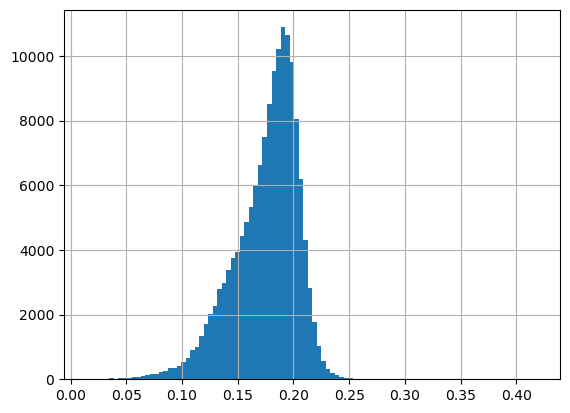

In [71]:
ids.identity.hist(bins=100)

Highest identity is 0.47 and in general the most identical sequences are different GPCRs.

<br>

In [72]:
ids.query(f"pdb1 in {list(mmer_clust_ids.keys())} or pdb2 in {list(mmer_clust_ids.keys())}").sort_values("identity", ascending=False).iloc[:50]

,pdb1,seqid1,pdb2,seqid2,identity
63061,5x33,1,7e40,2,0.362023
12774,5xez,1,7e40,2,0.344870
123221,5icn,2,7p2v,1,0.317258
91185,8tb7,1,9dnm,3,0.316827
143554,5ixe,1,6z1m,1,0.312277
144346,6rmd,2,8jb3,1,0.310502
100328,4r1r,1,7agj,1,0.310061
86643,6mc1,1,8tk3,1,0.301111
142153,7aud,1,7gqu,1,0.299118
92497,1peo,1,7agj,1,0.291819


## Save

In [78]:
diverse_newsf = f"{extra_path}/diverse_news.pkl"

if not os.path.isfile(diverse_newsf):
    diverse_news = {
        p.lower(): m
        for p, m in news.items()
        if any(
            p.lower() in k
            for k in final_monomers
        )
    }
    
    with open(diverse_newsf, "wb") as f:
        pickle.dump(diverse_news, f)
else:
    with open(diverse_newsf, "rb") as f:
        diverse_news = pickle.load(f)

len(diverse_news), diverse_news

(30,
 {'21du': {'label_asym_id': ['F']},
  '22mj': {'label_asym_id': ['H']},
  '6s3a': {'label_asym_id': ['B']},
  '6vvq': {'label_asym_id': ['E']},
  '6z1m': {'label_asym_id': ['D']},
  '7e40': {'label_asym_id': ['F']},
  '7f8p': {'label_asym_id': ['G']},
  '7gqu': {'label_asym_id': ['D']},
  '7p2v': {'label_asym_id': ['F']},
  '7qpn': {'label_asym_id': ['C']},
  '7u4k': [{'label_asym_id': ['B']}],
  '7v39': [{'label_asym_id': ['F']}],
  '7yg5': {'label_asym_id': ['V']},
  '7zpe': {'label_asym_id': ['G']},
  '8cgw': {'label_asym_id': ['P']},
  '8crc': {'label_asym_id': ['C']},
  '8f4s': {'label_asym_id': ['D']},
  '8fpi': {'label_asym_id': ['F']},
  '8jp0': {'label_asym_id': ['B']},
  '8qtk': {'label_asym_id': ['E']},
  '8uk6': {'label_asym_id': ['C']},
  '8v81': {'label_asym_id': ['L']},
  '8y6w': {'label_asym_id': ['G']},
  '9dol': {'label_asym_id': ['F']},
  '9ebs': {'label_asym_id': ['F']},
  '9fsj': {'label_asym_id': ['B']},
  '9mfs': {'label_asym_id': ['B']},
  '9o2m': {'label_a

# Pockets

## FPocket utils

In [79]:
from utils.pocket_utils import Pocket, get_pocket_view, get_pockets_info, get_mean_pocket_features

In [80]:
view_pocket = lambda pdb, pocket: get_pocket_view(
    pdb = pdb, 
    cif = Cif(pdb),
    pocket = pocket,
    pockets_path = extra_pockets_path,
    sites = news_sites[pdb]
)

## "Old" FPocket

In [95]:
def hunt_pockets(pdb):    
    path = f"{extra_pockets_path}/{pdb}"
    if os.path.isdir(path):
        return
    else:
        print(pdb)
        os.makedirs(path, exist_ok=True)
        os.system(f"cp {extra_structures_path}/{pdb}.cif {path}/")
        os.system(f"fpocket -m 3 -M 6 -i 35 --file {path}/{pdb}.cif") # utils/external/fpocket/bin/fpocket

In [96]:
for pdb in tqdm(diverse_news, smoothing=0):
    hunt_pockets(pdb)

  0%|          | 0/30 [00:00<?, ?it/s]

7e40
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
7f8p
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
7u4k
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
7v39
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
8cgw
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 
9o2m
***** POCKET HUNTING BEGINS ***** 
***** POCKET HUNTING ENDS ***** 


### Process

In [97]:
pockets = pd.DataFrame((
    pocket
    for pdb in tqdm(diverse_news, smoothing=0)
    for pocket in get_pockets_info(
        Cif(pdb), 
        sites = news_sites[pdb],
        pockets_path = extra_pockets_path
    )
))

pockets

  0%|          | 0/30 [00:00<?, ?it/s]

,pdb,pocket,nres,site_in_pocket,pocket_in_site
0,21du,pocket7,9,0.0,0.0
1,21du,pocket1,21,0.0,0.0
2,21du,pocket2,12,0.0,0.0
3,21du,pocket4,10,0.0,0.0
4,21du,pocket9,11,0.0,0.0
...,...,...,...,...,...
588,9oul,pocket5,17,0.0,0.0
589,9oul,pocket8,14,0.0,0.0
590,9oul,pocket3,12,0.0,0.0
591,9oul,pocket12,15,0.0,0.0


In [98]:
len(diverse_news), len(pockets.pdb.unique())

(30, 30)

### Pocket size

In [99]:
pockets.sort_values("nres", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site
526,9mfs,pocket1,132,0.173913,0.030303
422,8v81,pocket1,125,0.962963,0.208000
78,7gqu,pocket1,123,0.896552,0.211382
582,9oul,pocket1,108,0.903226,0.259259
437,8v81,pocket43,105,0.000000,0.000000
...,...,...,...,...,...
497,9ebs,pocket12,7,0.000000,0.000000
56,7e40,pocket7,6,0.200000,0.333333
62,7e40,pocket5,6,0.000000,0.000000
342,8jp0,pocket32,6,0.000000,0.000000


<Axes: >

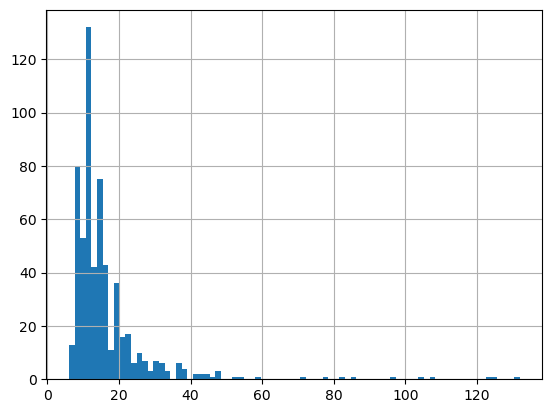

In [100]:
pockets.nres.hist(bins=80)

### Labelling

In [101]:
pockets.loc[
    pockets.loc[
        lambda x: round(x["site_in_pocket"], 2) >= 0.65
    ].index, 
    "label"
] = 1
pockets["label"] = pockets["label"].fillna(0).astype(int)

pockets.sort_values("label", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
31,6vvq,pocket1,36,0.736842,0.777778,1
566,9prs,pocket1,44,0.727273,0.545455,1
203,7zpe,pocket3,19,0.785714,0.578947,1
422,8v81,pocket1,125,0.962963,0.208000,1
529,9mfs,pocket32,19,0.782609,0.947368,1
...,...,...,...,...,...,...
204,7zpe,pocket6,11,0.000000,0.000000,0
205,8cgw,pocket16,13,0.000000,0.000000,0
206,8cgw,pocket28,11,0.000000,0.000000,0
207,8cgw,pocket18,21,0.000000,0.000000,0


In [130]:
pockets.sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
422,8v81,pocket1,125,0.962963,0.208000,1
388,8uk6,pocket1,37,0.952381,0.540541,1
13,22mj,pocket2,44,0.928571,0.590909,1
109,7qpn,pocket2,30,0.913043,0.700000,1
582,9oul,pocket1,108,0.903226,0.259259,1
78,7gqu,pocket1,123,0.896552,0.211382,1
487,9ebs,pocket7,48,0.857143,0.500000,1
257,8f4s,pocket1,30,0.846154,0.733333,1
54,6z1m,pocket6,41,0.833333,0.731707,1
203,7zpe,pocket3,19,0.785714,0.578947,1


In [102]:
dropped = set(pockets.pdb.unique()) - set(pockets.loc[pockets.label == 1].pdb.unique())

print("Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs")
len(pockets.pdb.unique()), len(pockets.loc[pockets.label == 1].pdb.unique()), len(dropped), len(dropped)/len(pockets.pdb.unique()), dropped

Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs


(30,
 22,
 8,
 0.26666666666666666,
 {'21du', '7e40', '7f8p', '7u4k', '7v39', '8cgw', '8y6w', '9dol'})

In [103]:
print("Total pockets, positive pockets, and ratio of positive pockets")
len(pockets), sum(pockets.label == 1), sum(pockets.label == 1)/len(pockets.query(f"pdb not in {list(dropped)}"))

Total pockets, positive pockets, and ratio of positive pockets


(593, 22, 0.04592901878914405)

In [110]:
pockets.query("pdb == '21du'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
0,21du,pocket7,9,0.0,0.0,0
1,21du,pocket1,21,0.0,0.0,0
2,21du,pocket2,12,0.0,0.0,0
3,21du,pocket4,10,0.0,0.0,0
4,21du,pocket9,11,0.0,0.0,0
5,21du,pocket10,6,0.0,0.0,0
6,21du,pocket5,25,0.0,0.0,0
7,21du,pocket8,14,0.0,0.0,0
8,21du,pocket3,17,0.0,0.0,0
9,21du,pocket6,9,0.0,0.0,0


In [111]:
pockets.query("pdb == '7e40'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
57,7e40,pocket1,17,0.3,0.176471,0
61,7e40,pocket10,8,0.3,0.375000,0
56,7e40,pocket7,6,0.2,0.333333,0
55,7e40,pocket11,12,0.0,0.000000,0
58,7e40,pocket2,12,0.0,0.000000,0
59,7e40,pocket4,9,0.0,0.000000,0
60,7e40,pocket9,9,0.0,0.000000,0
62,7e40,pocket5,6,0.0,0.000000,0
63,7e40,pocket8,9,0.0,0.000000,0
64,7e40,pocket3,8,0.0,0.000000,0


In [112]:
pockets.query("pdb == '7f8p'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
70,7f8p,pocket5,17,0.583333,0.823529,0
67,7f8p,pocket1,21,0.083333,0.095238,0
68,7f8p,pocket2,11,0.000000,0.000000,0
69,7f8p,pocket4,12,0.000000,0.000000,0
71,7f8p,pocket3,13,0.000000,0.000000,0
72,7f8p,pocket6,14,0.000000,0.000000,0


In [113]:
pockets.query("pdb == '7u4k'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
118,7u4k,pocket1,14,0.0,0.0,0
119,7u4k,pocket2,10,0.0,0.0,0
120,7u4k,pocket3,9,0.0,0.0,0


In [114]:
pockets.query("pdb == '7v39'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
122,7v39,pocket1,17,0.333333,0.176471,0
121,7v39,pocket7,14,0.000000,0.000000,0
123,7v39,pocket2,16,0.000000,0.000000,0
124,7v39,pocket4,13,0.000000,0.000000,0
125,7v39,pocket5,10,0.000000,0.000000,0
126,7v39,pocket3,11,0.000000,0.000000,0
127,7v39,pocket6,16,0.000000,0.000000,0


In [115]:
pockets.query("pdb == '8cgw'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
221,8cgw,pocket1,71,0.222222,0.056338,0
230,8cgw,pocket9,23,0.111111,0.086957,0
240,8cgw,pocket19,22,0.111111,0.090909,0
209,8cgw,pocket34,11,0.111111,0.181818,0
226,8cgw,pocket4,12,0.055556,0.083333,0
244,8cgw,pocket41,27,0.055556,0.037037,0
205,8cgw,pocket16,13,0.000000,0.000000,0
207,8cgw,pocket18,21,0.000000,0.000000,0
206,8cgw,pocket28,11,0.000000,0.000000,0
213,8cgw,pocket7,9,0.000000,0.000000,0


In [116]:
pockets.query("pdb == '8y6w'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
455,8y6w,pocket2,12,0.250000,0.250000,0
461,8y6w,pocket3,14,0.083333,0.071429,0
456,8y6w,pocket4,11,0.083333,0.090909,0
451,8y6w,pocket11,9,0.000000,0.000000,0
452,8y6w,pocket7,9,0.000000,0.000000,0
454,8y6w,pocket1,21,0.000000,0.000000,0
453,8y6w,pocket13,13,0.000000,0.000000,0
458,8y6w,pocket10,12,0.000000,0.000000,0
457,8y6w,pocket9,8,0.000000,0.000000,0
459,8y6w,pocket5,12,0.000000,0.000000,0


In [117]:
pockets.query("pdb == '9dol'").sort_values("site_in_pocket", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
484,9dol,pocket21,32,0.512195,0.656250,0
469,9dol,pocket22,22,0.414634,0.772727,0
481,9dol,pocket3,23,0.121951,0.217391,0
472,9dol,pocket1,48,0.097561,0.083333,0
465,9dol,pocket18,10,0.000000,0.000000,0
464,9dol,pocket16,10,0.000000,0.000000,0
468,9dol,pocket7,19,0.000000,0.000000,0
467,9dol,pocket15,9,0.000000,0.000000,0
466,9dol,pocket11,9,0.000000,0.000000,0
470,9dol,pocket13,11,0.000000,0.000000,0


In [121]:
final_pockets = pockets

### Features

In [122]:
final_pockets = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: pd.Series(
                Pocket(f"{extra_pockets_path}/{row['pdb']}/{row['pdb']}_out/pockets/{row['pocket']}_atm.cif").feats
            ), axis=1
        )
    ),
    axis=1
)

final_pockets

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label,Pocket Score,Drug Score,Number of alpha spheres,Mean alpha-sphere radius,...,Local hydrophobic density Score,Number of apolar alpha sphere,Proportion of apolar alpha sphere,Total SASA,Polar SASA,Apolar SASA,Proportion of polar atoms,Alpha sphere density,Cent. of mass - Alpha Sphere max dist,Flexibility
0,21du,pocket7,9,0.0,0.0,0,0.1392,0.0245,55.0,3.4301,...,17.0000,18.0,0.3273,118.045,41.964,76.081,37.838,4.691,11.475,0.146
1,21du,pocket1,21,0.0,0.0,0,0.5972,0.9006,126.0,3.3671,...,39.8644,59.0,0.4683,106.054,55.176,50.879,35.385,5.713,13.170,0.673
2,21du,pocket2,12,0.0,0.0,0,0.3810,0.0263,37.0,3.1704,...,17.8000,20.0,0.5405,11.668,3.214,8.453,32.143,3.683,7.088,0.367
3,21du,pocket4,10,0.0,0.0,0,0.2260,0.1959,40.0,3.4188,...,22.5185,27.0,0.6750,61.339,2.165,59.174,20.690,4.105,10.639,0.385
4,21du,pocket9,11,0.0,0.0,0,-0.0244,0.0050,60.0,3.5061,...,8.8000,15.0,0.2500,186.377,71.336,115.041,42.553,5.333,11.530,0.480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,9oul,pocket5,17,0.0,0.0,0,0.0408,0.0033,56.0,3.4169,...,7.0000,8.0,0.1429,136.946,86.226,50.720,50.000,5.938,14.043,0.207
589,9oul,pocket8,14,0.0,0.0,0,0.0130,0.0720,56.0,3.5528,...,26.6061,33.0,0.5893,130.797,26.941,103.856,39.024,5.450,13.895,0.303
590,9oul,pocket3,12,0.0,0.0,0,0.2121,0.0759,40.0,3.3137,...,32.5946,37.0,0.9250,25.360,0.000,25.360,14.815,3.529,8.307,0.185
591,9oul,pocket12,15,0.0,0.0,0,-0.0517,0.8259,90.0,3.5608,...,60.9394,66.0,0.7333,122.014,33.857,88.157,26.000,3.965,12.101,0.208


In [123]:
final_pockets.to_pickle(f"{extra_path}/pockets.pkl")

# Features

Copied and edited the features_scripts into `7.Extra_set`, then ran:

In [87]:
import subprocess

In [91]:
subprocess.run("""
cd 7.Extra_set &&
python features.py > features.log 2>&1 &&
python transferentropy_features.py > transferentropy.log 2>&1 &&
python prody_features.py > prody.log 2>&1 &&
python hhblits_features.py > hhblits.log 2>&1
""", shell=True)

CompletedProcess(args='\ncd 7.Extra_set &&\npython features.py > features.log 2>&1 &&\npython transferentropy_features.py > transferentropy.log 2>&1 &&\npython prody_features.py > prody.log 2>&1 &&\npython hhblits_features.py > hhblits.log 2>&1\n', returncode=0)

In [124]:
from utils.features_utils import calculate_features
from utils.features_classes import BiopythonF, DSSPF

BiopythonF.dssp_path = "/home/fnerin/Desktop/AlloPockets/training_data/utils/external/mkdssp-4.4.0-linux-x64"

for pdb in diverse_news:
    print(pdb, flush=True)
    pdbpath = f"{extra_path}/features/{pdb}"
    file = f"{pdbpath}/{DSSPF.__name__}.pkl"
    if not os.path.isfile(file):
        os.makedirs(pdbpath, exist_ok=True)
        calculate_features(pdb, DSSPF, file, extra_structures_path, extra_original_cifs_path)

┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2024 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python311.Release 2024.42+release.3366cf78a3df04339d1982e94531b77b098ddb99 2024-10-11T08:24:04] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.conda.ubuntu.cxx11thread.ser

In [90]:
errors = pd.concat((
    pd.read_csv(f"{extra_features_path}/{f}", sep="\t", header=None) 
    for f in os.listdir(extra_features_path) 
        if f.endswith("errors.txt")
))

errors

ValueError: No objects to concatenate

In [139]:
errors_pdbs = []
missing = []

In [140]:
for pdb in final_pockets.pdb.unique():
    if pdb not in errors_pdbs:
        files = tuple(f for f in os.listdir(f"{extra_features_path}/features/{pdb}") if f.endswith(".pkl"))
        miss = tuple(
            fc 
            for fc in ('GrapheinF', 'FreeSASAF', 'DSSPF', 'MelodiaF', 'BiopythonF', 'ProDyF', 'PyRosettaF', 'TransferEntropyF', 'HHBlitsF') 
            if f"{fc}.pkl" not in files
        )
        if len(miss):
            missing.append((pdb, miss))

missing

[]

## Processing

In [141]:
from utils.features_utils import get_pdb_features

In [142]:
featuresf = f"{extra_path}/features.pkl"

if not os.path.isfile(featuresf):
    featuresd = {}
    for pdb in tqdm(final_pockets.pdb.unique(), smoothing=0):
        if pdb not in errors_pdbs:
        # if len(errors_pdbs) == 0 and len(missing) == 0:
            feats = get_pdb_features(
                Cif(pdb),
                sites = [d["site"] for d in news_sites[pdb]],
                features_path = extra_features_path
            )
            
            featuresd[pdb] = pd.concat(
                (
                    pd.DataFrame([pdb]*len(feats), columns=pd.MultiIndex.from_tuples([("Residues", "pdb")])),
                    feats
                ),
                axis=1
            )
    with open(featuresf, "wb") as f:
        pickle.dump(featuresd, f)
else:
    with open(featuresf, "rb") as f:
        featuresd = pickle.load(f)

len(featuresd), featuresd

  0%|          | 0/30 [00:00<?, ?it/s]

('9o2m', 'DSSPF', 'dssp') Not all feature columns {'pdbx_PDB_ins_code', 'auth_seq_id', 'auth_asym_id'}


(30,
 {'21du':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       21du               5             E          264            R   
  1       21du               5             E          265            R   
  2       21du               5             E          266            R   
  3       21du               5             E          267            R   
  4       21du               5             E          268            R   
  ..       ...             ...           ...          ...          ...   
  273     21du               5             E          546            R   
  274     21du               5             E          547            R   
  275     21du               5             E          548            R   
  276     21du               5             E          549            R   
  277     21du               5             E          550            R   
  
                      

### Per-pocket

In [143]:
final_pockets = pd.concat(
    (
        final_pockets[["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site']],
        final_pockets["label"],
        final_pockets.drop(columns=["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site', 'label'])
    ),
    axis=1,
    keys=["Pockets", "Label", "FPocket"]
)

final_pockets

Pockets                                              Label      FPocket  \
        pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0      21du   pocket7    9            0.0            0.0     0       0.1392   
1      21du   pocket1   21            0.0            0.0     0       0.5972   
2      21du   pocket2   12            0.0            0.0     0       0.3810   
3      21du   pocket4   10            0.0            0.0     0       0.2260   
4      21du   pocket9   11            0.0            0.0     0      -0.0244   
..      ...       ...  ...            ...            ...   ...          ...   
588    9oul   pocket5   17            0.0            0.0     0       0.0408   
589    9oul   pocket8   14            0.0            0.0     0       0.0130   
590    9oul   pocket3   12            0.0            0.0     0       0.2121   
591    9oul  pocket12   15            0.0            0.0     0      -0.0517   
592    9oul   pocket6   12            0.0            0.0     0       0.0368   

                                                                 ...  \
    Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0       0.0245                    55.0                   3.4301  ...   
1       0.9006                   126.0                   3.3671  ...   
2       0.0263                    37.0                   3.1704  ...   
3       0.1959                    40.0                   3.4188  ...   
4       0.0050                    60.0                   3.5061  ...   
..         ...                     ...                      ...  ...   
588     0.0033                    56.0                   3.4169  ...   
589     0.0720                    56.0                   3.5528  ...   
590     0.0759                    40.0                   3.3137  ...   
591     0.8259                    90.0                   3.5608  ...   
592     0.0043                    44.0                   3.5140  ...   

                                                                   \
    Local hydrophobic density Score Number of apolar alpha sphere   
0                           17.0000                          18.0   
1                           39.8644                          59.0   
2                           17.8000                          20.0   
3                           22.5185                          27.0   
4                            8.8000                          15.0   
..                              ...                           ...   
588                          7.0000                           8.0   
589                         26.6061                          33.0   
590                         32.5946                          37.0   
591                         60.9394                          66.0   
592                         11.6923                          13.0   

                                                                         \
    Proportion of apolar alpha sphere Total SASA Polar SASA Apolar SASA   
0                              0.3273    118.045     41.964      76.081   
1                              0.4683    106.054     55.176      50.879   
2                              0.5405     11.668      3.214       8.453   
3                              0.6750     61.339      2.165      59.174   
4                              0.2500    186.377     71.336     115.041   
..                                ...        ...        ...         ...   
588                            0.1429    136.946     86.226      50.720   
589                            0.5893    130.797     26.941     103.856   
590                            0.9250     25.360      0.000      25.360   
591                            0.7333    122.014     33.857      88.157   
592                            0.2955     87.139     29.173      57.966   

                                                    \
    Proportion of polar atoms Alpha sphere density   
0                      37.838                4.691   
1  

In [144]:
from utils.pocket_utils import get_mean_pocket_features
extra_pockets_path = "7.Extra_set/pockets"

In [145]:
pockets_features = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = featuresd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1
)

In [146]:
pockets_features

Pockets                                              Label      FPocket  \
        pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0      21du   pocket7    9            0.0            0.0     0       0.1392   
1      21du   pocket1   21            0.0            0.0     0       0.5972   
2      21du   pocket2   12            0.0            0.0     0       0.3810   
3      21du   pocket4   10            0.0            0.0     0       0.2260   
4      21du   pocket9   11            0.0            0.0     0      -0.0244   
..      ...       ...  ...            ...            ...   ...          ...   
588    9oul   pocket5   17            0.0            0.0     0       0.0408   
589    9oul   pocket8   14            0.0            0.0     0       0.0130   
590    9oul   pocket3   12            0.0            0.0     0       0.2121   
591    9oul  pocket12   15            0.0            0.0     0      -0.0517   
592    9oul   pocket6   12            0.0            0.0     0       0.0368   

                                                                 ...  \
    Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0       0.0245                    55.0                   3.4301  ...   
1       0.9006                   126.0                   3.3671  ...   
2       0.0263                    37.0                   3.1704  ...   
3       0.1959                    40.0                   3.4188  ...   
4       0.0050                    60.0                   3.5061  ...   
..         ...                     ...                      ...  ...   
588     0.0033                    56.0                   3.4169  ...   
589     0.0720                    56.0                   3.5528  ...   
590     0.0759                    40.0                   3.3137  ...   
591     0.8259                    90.0                   3.5608  ...   
592     0.0043                    44.0                   3.5140  ...   

      HHBlits                                                              \
         M->M      M->I      M->D      I->M      I->I      D->M      D->D   
0    0.932576  0.047930  0.019539  0.258842  0.741182  0.351618  0.648369   
1    0.959654  0.013198  0.027168  0.225122  0.774876  0.166789  0.833207   
2    0.990885  0.002729  0.006320  0.357020  0.642951  0.207145  0.792905   
3    0.991608  0.002889  0.005459  0.238687  0.761310  0.171671  0.828261   
4    0.954969  0.028346  0.016624  0.145902  0.854117  0.212397  0.787656   
..        ...       ...       ...       ...       ...       ...       ...   
588  0.963000  0.031900  0.005122  0.387824  0.494491  0.390824  0.609183   
589  0.852883  0.060658  0.086446  0.263107  0.736924  0.182295  0.817684   
590  0.985923  0.007104  0.006943  0.337138  0.662870  0.322538  0.677475   
591  0.987823  0.006764  0.005424  0.153494  0.313180  0.169040  0.830898   
592  0.980933  0.012603  0.006591  0.444556  0.472120  0.324317  0.675635   

                                    
          Neff    Neff_I    Neff_D  
0    12.118111  1.785000  2.023222  
1    11.965714  1.221619  2.413429  
2    12.018333  1.050250  1.440750  
3    11.991500  1.049900  1.388500  
4    12.031636  1.601455  2.225818  
..         ...       ...       ...  
588   9.763000  1.151059  1.207941  
589   9.575071  1.333714  3.953429  
590  10.024417  1.066333  1.186667  
591   7.277400  0.500133  1.078333  
592   9.735917  1.010250  1.188833  

[593 rows x 194 columns]

In [147]:
pockets_featuresf = f"{extra_path}/pockets_features.pkl"

if not os.path.isfile(pockets_featuresf):
    pockets_featuresd = {
        pdb: pks
        for pdb, pks in pockets_features.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_featuresf, "wb") as f:
        pickle.dump(pockets_featuresd, f)
else:
    with open(pockets_featuresf, "rb") as f:
        pockets_featuresd = pickle.load(f)

len(pockets_featuresd), pockets_featuresd

(30,
 {'21du':   Pockets                                              Label      FPocket  \
        pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
  0    21du   pocket7    9            0.0            0.0     0       0.1392   
  1    21du   pocket1   21            0.0            0.0     0       0.5972   
  2    21du   pocket2   12            0.0            0.0     0       0.3810   
  3    21du   pocket4   10            0.0            0.0     0       0.2260   
  4    21du   pocket9   11            0.0            0.0     0      -0.0244   
  5    21du  pocket10    6            0.0            0.0     0      -0.1521   
  6    21du   pocket5   25            0.0            0.0     0       0.2005   
  7    21du   pocket8   14            0.0            0.0     0       0.0783   
  8    21du   pocket3   17            0.0            0.0     0       0.3379   
  9    21du   pocket6    9            0.0            0.0     0       0.1658   
  
                                    

# Embeddings

In [ ]:
########################################################
#### news_seqs doesn't have whole-sequences anymore ####
########################################################

In [148]:
seq_embsf = f"{extra_path}/seq_embeddings.pkl"

if not os.path.isfile(seq_embsf):
    from utils.embeddings import get_embs

    seq_embsd = {}
    for (pdb, entity_id, asym_id), seq in news_seqs.items():
        if pdb in featuresd:
            if pdb not in seq_embsd:
                seq_embsd[pdb] = {}
            if entity_id not in seq_embsd[pdb]:
                seq_embsd[pdb][entity_id] = {
                    "seq": seq,
                    "embs": get_embs(seq)
                }
        
    with open(seq_embsf, "wb") as f:
        pickle.dump(seq_embsd, f)
else:
    with open(seq_embsf, "rb") as f:
        seq_embsd = pickle.load(f)

len(seq_embsd), seq_embsd

2026-04-23 16:13:54.605330: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 16:13:54.807058: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Some weights of EsmModel were not initialized from the model checkpoint at /data/fnerin/huggingface/hub/models--facebook--esm2_t33_650M_UR50D/snapshots/08e4846e537177426273712802403f7ba8261b6c and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able t

(30,
 {'21du': {'5': {'seq': 'THFGVLMDLPRSASQLDARNTKVLTFISYIGCGISAIFSAATLLTYVAFEKLRRDYPSKILMNLSTALLFLNLLFLLDGWITSFNVDGLCIAVAVLLHFFLLATFTWMGLEAIHMYIALVKVFNTYIRRYILKFCIIGWGLPALVVSVVLASRNNNEVYGKESYGKEKGDEFCWIQDPVIFYVTCAGYFGVMFFLNIAMFIVVMVQICGRNGKRSNRTLREEVLRNLRSVVSLTFLLGMTWGFAFFAWGPLNIPFMYLFSIFNSLQGLFIFIFHCAMKENVQKQWRQ',
    'embs': array([[-0.1145128 ,  0.14297086, -0.08897851, ...,  0.11049924,
            -0.05185096, -0.20815158],
           [-0.07177661,  0.05940858,  0.03486217, ..., -0.10144694,
             0.03903483, -0.04504756],
           [-0.04930365,  0.05144559,  0.22764659, ..., -0.08295101,
            -0.19557862, -0.12972355],
           ...,
           [ 0.16462758, -0.3739897 , -0.2617354 , ..., -0.24443772,
             0.04300995, -0.01833791],
           [ 0.23407738,  0.38609365, -0.0037881 , ...,  0.06359814,
             0.23770003,  0.06347456],
           [-0.0262931 ,  0.09775974, -0.05033636, ...,  0.12803045,
             0.20906377, -0.11194369]], dtype=f

In [149]:
embsf = f"{extra_path}/embeddings.pkl"

if not os.path.isfile(embsf):
    embsd = {}
    for pdb, embs in tqdm(seq_embsd.items(), smoothing=0):
        residues = featuresd[pdb][["Residues", "Label"]]

        embsd[pdb] = residues.merge(
            pd.concat((
                pd.concat(
                    (
                        pd.Series([entity_id]*len(entd["seq"]), name="label_entity_id"),
                        pd.Series(range(1, len(entd["seq"])+1), name="label_seq_id", dtype=str),
                        pd.DataFrame(entd["embs"])
                    ),
                    axis=1,
                    keys=["Residues", "Residues", "Embeddings"]
                )
                for entity_id, entd in embs.items()
            )),
            on=[("Residues", "label_entity_id"), ("Residues", "label_seq_id")]
        )
        
    with open(embsf, "wb") as f:
        pickle.dump(embsd, f)
else:
    with open(embsf, "rb") as f:
        embsd = pickle.load(f)

len(embsd), embsd

  0%|          | 0/30 [00:00<?, ?it/s]

(30,
 {'21du':    Residues                                                          \
          pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0      21du               5             E          264            R   
  1      21du               5             E          265            R   
  2      21du               5             E          266            R   
  3      21du               5             E          267            R   
  4      21du               5             E          268            R   
  5      21du               5             E          269            R   
  6      21du               5             E          270            R   
  7      21du               5             E          271            R   
  8      21du               5             E          272            R   
  9      21du               5             E          273            R   
  10     21du               5             E          274            R   
  11     21du               5         

## Per-pocket

In [150]:
pockets_embeddings = pd.concat(
    (
        final_pockets[["Pockets", "Label"]],
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = embsd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1,
)

pockets_embeddings

Pockets                                              Label Embeddings  \
        pdb    pocket nres site_in_pocket pocket_in_site label          0   
0      21du   pocket7    9            0.0            0.0     0        NaN   
1      21du   pocket1   21            0.0            0.0     0  -0.009378   
2      21du   pocket2   12            0.0            0.0     0        NaN   
3      21du   pocket4   10            0.0            0.0     0        NaN   
4      21du   pocket9   11            0.0            0.0     0        NaN   
..      ...       ...  ...            ...            ...   ...        ...   
588    9oul   pocket5   17            0.0            0.0     0   0.064522   
589    9oul   pocket8   14            0.0            0.0     0   0.144209   
590    9oul   pocket3   12            0.0            0.0     0  -0.067827   
591    9oul  pocket12   15            0.0            0.0     0   0.020064   
592    9oul   pocket6   12            0.0            0.0     0   0.097752   

                                   ...                                \
            1         2         3  ...      1270      1271      1272   
0         NaN       NaN       NaN  ...       NaN       NaN       NaN   
1   -0.420387 -0.240972  0.091571  ... -0.114793 -0.223268 -0.196106   
2         NaN       NaN       NaN  ...       NaN       NaN       NaN   
3         NaN       NaN       NaN  ...       NaN       NaN       NaN   
4         NaN       NaN       NaN  ...       NaN       NaN       NaN   
..        ...       ...       ...  ...       ...       ...       ...   
588 -0.024316  0.059127  0.009882  ...  0.071459 -0.082641 -0.106133   
589  0.053666 -0.037706  0.196185  ... -0.007436 -0.105935 -0.072950   
590 -0.046490  0.063479 -0.008138  ...  0.069293 -0.091590 -0.101447   
591 -0.084291 -0.075839  0.125133  ... -0.021168 -0.132142  0.031237   
592  0.052417 -0.032212  0.080748  ...  0.063908 -0.134794 -0.055729   

                                                                           
         1273      1274      1275      1276      1277      1278      1279  
0         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
1    0.230169  0.026174  0.099086  0.016138 -0.318419  0.114385  0.266228  
2         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
3         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
4         NaN       NaN       NaN       NaN       NaN       NaN       NaN  
..        ...       ...       ...       ...       ...       ...       ...  
588  0.008057 -0.056312  0.024593  0.214184 -0.100024 -0.053200  0.069540  
589  0.056434  0.050766 -0.029884  0.195749 -0.204927 -0.090371  0.149893  
590  0.095764 -0.048660  0.052685  0.093635 -0.135882 -0.074784  0.189494  
591 -0.034149  0.047874 -0.008111  0.046026 -0.263428 -0.154662  0.077141  
592 -0.003184  0.079676  0.000639  0.109480 -0.013768 -0.069318 -0.025336  

[593 rows x 1286 columns]

In [151]:
pockets_embeddingsf = f"{extra_path}/pockets_embeddings.pkl"

if not os.path.isfile(pockets_embeddingsf):
    pockets_embeddingsd = {
        pdb: pks
        for pdb, pks in pockets_embeddings.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_embeddingsf, "wb") as f:
        pickle.dump(pockets_embeddingsd, f)
else:
    with open(pockets_embeddingsf, "rb") as f:
        pockets_embeddingsd = pickle.load(f)

len(pockets_embeddingsd), pockets_embeddingsd

(30,
 {'21du':   Pockets                                              Label Embeddings  \
        pdb    pocket nres site_in_pocket pocket_in_site label          0   
  0    21du   pocket7    9            0.0            0.0     0        NaN   
  1    21du   pocket1   21            0.0            0.0     0  -0.009378   
  2    21du   pocket2   12            0.0            0.0     0        NaN   
  3    21du   pocket4   10            0.0            0.0     0        NaN   
  4    21du   pocket9   11            0.0            0.0     0        NaN   
  5    21du  pocket10    6            0.0            0.0     0        NaN   
  6    21du   pocket5   25            0.0            0.0     0   0.002370   
  7    21du   pocket8   14            0.0            0.0     0        NaN   
  8    21du   pocket3   17            0.0            0.0     0        NaN   
  9    21du   pocket6    9            0.0            0.0     0        NaN   
  
                                   ...                      